In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# 1. Load GloVe Embeddings
def load_glove_embeddings(glove_file_path):
    print(f"Loading GloVe embeddings from {glove_file_path}...")
    embeddings_index = {}
    try:
        with open(glove_file_path, encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                # Handle cases where a line might be malformed
                try:
                    coefs = np.asarray(values[1:], dtype='float32')
                    embeddings_index[word] = coefs
                except ValueError:
                    continue
        print(f"Found {len(embeddings_index)} word vectors.")
        return embeddings_index
    except FileNotFoundError:
        print(f"Error: File not found at {glove_file_path}")
        print("Please ensure 'glove.6B.100d.txt' is in the correct directory.")
        return {}

# 2. Generate Averaged Embeddings (Pure Python/Numpy)
def get_averaged_glove_features(texts, embeddings_index, embedding_dim=100):
    """
    Converts a list of text strings into a list of averaged GloVe vectors.
    """
    features = []
    for text in tqdm(texts, desc="Vectorizing texts"):
        if not isinstance(text, str):
            text = ""

        # Simple tokenization: lowercase and split by whitespace
        words = text.lower().split()

        # Filter for words present in GloVe
        valid_vectors = [embeddings_index[w] for w in words if w in embeddings_index]

        if valid_vectors:
            # Average the vectors
            avg_vector = np.mean(valid_vectors, axis=0)
        else:
            # If no words found (or empty text), return zero vector
            avg_vector = np.zeros(embedding_dim)

        features.append(avg_vector)

    return np.array(features)

In [8]:
# glove_path = 'dolma_300_2024_1.2M.100_combined.txt'

# embeddings_index = load_glove_embeddings(glove_path)

# if embeddings_index:
#     # Load Data
#     print("Loading dataset...")
#     df = pd.read_csv("processed_datasets/WELFake_Dataset_processed.csv")

#     # Ensure text column is string
#     df['combined_text'] = df['combined_text'].astype(str)

#     texts = df['combined_text'].tolist()
#     labels = df['label'].values

#     # FIX: Determine embedding dimension from the loaded data automatically
#     # This prevents mismatch between loaded vectors and the zero-vector fallback
#     if len(embeddings_index) > 0:
#         sample_key = next(iter(embeddings_index))
#         embedding_dim = len(embeddings_index[sample_key])
#         print(f"Detected embedding dimension: {embedding_dim}")
#     else:
#         embedding_dim = 100 # Fallback default

#     # Generate Features
#     X_glove = get_averaged_glove_features(texts, embeddings_index, embedding_dim)

#     # Create DataFrame
#     glove_feature_cols = [f'glove_{i}' for i in range(embedding_dim)]
#     glove_df = pd.DataFrame(X_glove, columns=glove_feature_cols)
#     glove_df['label'] = labels

#     # Save
#     output_path = 'preprocessed_datasets/glove_features_averaged.csv'
#     glove_df.to_csv(output_path, index=False)
#     print(f"Averaged GloVe features saved to {output_path}")

In [9]:
def scale_data(dataframe, oversample=False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)

  if oversample:
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x, y)

  data = np.hstack((x, np.reshape(y, (-1, 1))))

  return data, x, y

In [10]:
def split_dataset(df):
    train = df.sample(frac=0.8, random_state=42)
    test = df.drop(train.index)
    print(f"Total rows in dataset: {len(df)}")
    print(f"Total rows in train set: {len(train)}")
    print(f"Total rows in test set: {len(test)}")

    print("\nClass distribution in full dataset:")
    print(df['label'].value_counts())

    print("\nClass distribution in train set:")
    print(train['label'].value_counts())

    print("\nClass distribution in test set:")
    print(test['label'].value_counts())

    train, xtrain, ytrain = scale_data(train)
    test, xtest, ytest = scale_data(test)

    print("\n KNN \n")

    return train, xtrain, ytrain, test, xtest, ytest

In [11]:
def train_ml_models(xtrain, ytrain, xtest, ytest):
    print("\n KNN \n")
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(xtrain, ytrain)

    ypred = knn_model.predict(xtest)
    print(classification_report(ytest, ypred))

    print("\n Gaussian NB \n")
    nb_model = GaussianNB()
    nb_model = nb_model.fit(xtrain, ytrain)

    ypred = nb_model.predict(xtest)

    print(classification_report(ytest, ypred))

    print("\n Logistica Regression \n")
    lgr_model = LogisticRegression(max_iter=1000)
    lgr_model = lgr_model.fit(xtrain, ytrain)

    ypred = lgr_model.predict(xtest)

    print(classification_report(ytest, ypred))

    print("\n Support Vector Classifier \n")
    svc_model = SVC()
    svc_model = svc_model.fit(xtrain, ytrain)

    ypred = svc_model.predict(xtest)
    print(classification_report(ytest, ypred))

    print("\n XGBoost \n")
    xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    xgb_model = xgb_model.fit(xtrain, ytrain)

    ypred = xgb_model.predict(xtest)
    print(classification_report(ytest, ypred))

    print("\n Random Forest Classifier \n")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(xtrain, ytrain)

    ypred = rf_model.predict(xtest)
    print(classification_report(ytest, ypred))

In [12]:
class CNNModel(nn.Module):
    def __init__(self, embedding_dim, num_filters=100, filter_sizes=[3, 4, 5]):
        super(CNNModel, self).__init__()
        self.embedding_dim = embedding_dim

        # Reshape input to (batch_size, 1, embedding_dim) for conv1d
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(num_filters * len(filter_sizes), 64)
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, embedding_dim)
        x = x.unsqueeze(1)  # (batch_size, 1, embedding_dim)

        # Apply convolutions
        conv_outputs = []
        for conv in self.conv_layers:
            conv_out = self.relu(conv(x))  # (batch_size, num_filters, length)
            pooled = torch.max(conv_out, dim=2)[0]  # Max pooling
            conv_outputs.append(pooled)

        # Concatenate all conv outputs
        x = torch.cat(conv_outputs, dim=1)  # (batch_size, num_filters * len(filter_sizes))

        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))

        return x

In [13]:
class LSTMModel(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=128, num_layers=2):
        super(LSTMModel, self).__init__()
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True, dropout=0.5)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, embedding_dim)
        x = x.unsqueeze(1)  # (batch_size, 1, embedding_dim) - add sequence dimension

        # LSTM forward pass
        lstm_out, (hidden, cell) = self.lstm(x)  # hidden: (num_layers, batch_size, hidden_dim)

        # Use last hidden state
        x = hidden[-1]  # (batch_size, hidden_dim)

        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))

        return x

In [14]:
class CNNLSTMModel(nn.Module):
    def __init__(self, embedding_dim, num_filters=64, filter_sizes=[3, 4, 5],
                 hidden_dim=128, num_layers=1):
        super(CNNLSTMModel, self).__init__()
        self.embedding_dim = embedding_dim

        # CNN layers
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        self.relu = nn.ReLU()

        # LSTM layers - input is concatenated conv outputs
        cnn_output_dim = num_filters * len(filter_sizes)
        self.lstm = nn.LSTM(input_size=cnn_output_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True, dropout=0.5)

        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, embedding_dim)
        x = x.unsqueeze(1)  # (batch_size, 1, embedding_dim)

        # Apply CNN
        conv_outputs = []
        for conv in self.conv_layers:
            conv_out = self.relu(conv(x))  # (batch_size, num_filters, length)
            pooled = torch.max(conv_out, dim=2)[0]  # Max pooling
            conv_outputs.append(pooled)

        x = torch.cat(conv_outputs, dim=1)  # (batch_size, cnn_output_dim)
        x = x.unsqueeze(1)  # (batch_size, 1, cnn_output_dim) - add sequence dimension

        # Apply LSTM
        lstm_out, (hidden, cell) = self.lstm(x)
        x = hidden[-1]  # (batch_size, hidden_dim)

        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))

        return x

In [15]:
def train_deep_learning_model(model, train_loader, test_loader, epochs=10, learning_rate=0.001, device='cpu'):
    """
    Train a PyTorch model and evaluate on test set.

    Parameters:
    - model: PyTorch model
    - train_loader: Training DataLoader
    - test_loader: Test DataLoader
    - epochs: Number of training epochs
    - learning_rate: Learning rate
    - device: 'cpu' or 'cuda'
    """

    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"Training on device: {device}")
    print(f"Model: {model.__class__.__name__}")
    print("=" * 50)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device).float()
            batch_y = batch_y.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Evaluate on test set
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(device).float()
                batch_y = batch_y.to(device).float().unsqueeze(1)

                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()

                # Calculate accuracy
                predicted = (outputs > 0.5).float()
                correct += (predicted == batch_y).sum().item()
                total += batch_y.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        accuracy = correct / total

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.4f}")

    print("=" * 50)
    print(f"{model.__class__.__name__} training completed!")

    return model

# ==================== Wrapper Function ====================
def train_all_deep_learning_models(xtrain, ytrain, xtest, ytest, epochs=10, batch_size=32):
    """
    Train CNN, LSTM, and CNN-LSTM models.

    Parameters:
    - xtrain, ytrain: Training data and labels
    - xtest, ytest: Test data and labels
    - epochs: Number of training epochs
    - batch_size: Batch size for DataLoader
    """

    # Determine device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Convert to PyTorch tensors
    xtrain_tensor = torch.from_numpy(xtrain).float()
    ytrain_tensor = torch.from_numpy(ytrain).long()
    xtest_tensor = torch.from_numpy(xtest).float()
    ytest_tensor = torch.from_numpy(ytest).long()

    # Create DataLoaders
    train_dataset = TensorDataset(xtrain_tensor, ytrain_tensor)
    test_dataset = TensorDataset(xtest_tensor, ytest_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    embedding_dim = xtrain.shape[1]

    # Train CNN
    print("\n" + "=" * 50)
    print("TRAINING CNN MODEL")
    print("=" * 50)
    cnn_model = CNNModel(embedding_dim)
    cnn_model = train_deep_learning_model(cnn_model, train_loader, test_loader, epochs=epochs, device=device)

    # Train LSTM
    print("\n" + "=" * 50)
    print("TRAINING LSTM MODEL")
    print("=" * 50)
    lstm_model = LSTMModel(embedding_dim)
    lstm_model = train_deep_learning_model(lstm_model, train_loader, test_loader, epochs=epochs, device=device)

    # Train CNN-LSTM
    print("\n" + "=" * 50)
    print("TRAINING CNN-LSTM HYBRID MODEL")
    print("=" * 50)
    cnn_lstm_model = CNNLSTMModel(embedding_dim)
    cnn_lstm_model = train_deep_learning_model(cnn_lstm_model, train_loader, test_loader, epochs=epochs, device=device)

    return cnn_model, lstm_model, cnn_lstm_model

In [16]:
def train_deep_learning_model(model, train_loader, val_loader, test_loader, epochs=10, learning_rate=0.001, device='cpu'):
    """
    Train a PyTorch model with validation set and evaluate on test set.

    Parameters:
    - model: PyTorch model
    - train_loader: Training DataLoader
    - val_loader: Validation DataLoader
    - test_loader: Test DataLoader (NOT USED during training, only for final evaluation)
    - epochs: Number of training epochs
    - learning_rate: Learning rate
    - device: 'cpu' or 'cuda'
    """

    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"Training on device: {device}")
    print(f"Model: {model.__class__.__name__}")
    print("=" * 50)

    # Storage for history
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device).float()
            batch_y = batch_y.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ==================== VALIDATION ====================
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device).float()
                batch_y = batch_y.to(device).float().unsqueeze(1)

                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

                # Calculate accuracy
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == batch_y).sum().item()
                val_total += batch_y.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}")

    print("=" * 50)
    print(f"{model.__class__.__name__} training completed!")

    # Test-set eval
    print("\n" + "=" * 50)
    print(f"FINAL EVALUATION ON TEST SET - {model.__class__.__name__}")
    print("=" * 50)

    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device).float()
            batch_y = batch_y.to(device).float().unsqueeze(1)

            outputs = model(batch_x)
            predicted = (outputs > 0.5).float()

            all_predictions.extend(predicted.cpu().numpy().flatten())
            all_labels.extend(batch_y.cpu().numpy().flatten())
            all_probabilities.extend(outputs.cpu().numpy().flatten())

    # Calculate metrics
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)

    test_accuracy = np.mean(all_predictions == all_labels)
    test_auc = roc_auc_score(all_labels, all_probabilities)

    print(f"\nTest Accuracy: {test_accuracy:.4f}")
    print(f"Test AUC Score: {test_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, target_names=['Fake (0)', 'Real (1)']))

    # Visualisation
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss curves
    axes[0, 0].plot(train_losses, label='Training Loss', marker='o')
    axes[0, 0].plot(val_losses, label='Validation Loss', marker='s')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title(f'{model.__class__.__name__} - Loss over Epochs')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Accuracy curve
    axes[0, 1].plot(val_accuracies, label='Validation Accuracy', marker='o', color='green')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title(f'{model.__class__.__name__} - Accuracy over Epochs')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False)
    axes[1, 0].set_xlabel('Predicted')
    axes[1, 0].set_ylabel('Actual')
    axes[1, 0].set_title(f'{model.__class__.__name__} - Confusion Matrix (Test Set)')
    axes[1, 0].set_xticklabels(['Fake (0)', 'Real (1)'])
    axes[1, 0].set_yticklabels(['Fake (0)', 'Real (1)'])

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probabilities)
    axes[1, 1].plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.4f})', color='darkorange', lw=2)
    axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].set_title(f'{model.__class__.__name__} - ROC Curve (Test Set)')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

    return model, {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'test_accuracy': test_accuracy,
        'test_auc': test_auc,
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probabilities
    }

In [17]:
def train_all_deep_learning_models(xtrain, ytrain, xtest, ytest, epochs=10, batch_size=32, val_split=0.2):
    """
    Train CNN, LSTM, and CNN-LSTM models with proper train/validation/test split.

    Parameters:
    - xtrain, ytrain: Training data and labels
    - xtest, ytest: Test data and labels (NOT used during training)
    - epochs: Number of training epochs
    - batch_size: Batch size for DataLoader
    - val_split: Fraction of training data to use for validation (default: 0.2)

    Verification:
    - Train set is partitioned into training and validation
    - Test set is NOT used during training, only for final evaluation
    """

    print("=" * 70)
    print("DATA SPLIT VERIFICATION")
    print("=" * 70)
    print(f"Training set size: {xtrain.shape[0]}")
    print(f"Test set size: {xtest.shape[0]}")
    print(f"Validation split: {val_split * 100}%")
    print(f"Effective training size: {int(xtrain.shape[0] * (1 - val_split))}")
    print(f"Effective validation size: {int(xtrain.shape[0] * val_split)}")
    print("✓ Test set will NOT be used during training phase")
    print("✓ Test set will ONLY be used for final evaluation")
    print("=" * 70 + "\n")

    # Determine device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Split training data into train and validation
    from sklearn.model_selection import train_test_split as sklearn_train_test_split
    xtrain_split, xval, ytrain_split, yval = sklearn_train_test_split(
        xtrain, ytrain, test_size=val_split, random_state=42, stratify=ytrain
    )

    # Convert to PyTorch tensors
    xtrain_tensor = torch.from_numpy(xtrain_split).float()
    ytrain_tensor = torch.from_numpy(ytrain_split).long()
    xval_tensor = torch.from_numpy(xval).float()
    yval_tensor = torch.from_numpy(yval).long()
    xtest_tensor = torch.from_numpy(xtest).float()
    ytest_tensor = torch.from_numpy(ytest).long()

    # Create DataLoaders
    train_dataset = TensorDataset(xtrain_tensor, ytrain_tensor)
    val_dataset = TensorDataset(xval_tensor, yval_tensor)
    test_dataset = TensorDataset(xtest_tensor, ytest_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    embedding_dim = xtrain.shape[1]

    models_history = {}

    # Train CNN
    print("\n" + "=" * 70)
    print("TRAINING CNN MODEL")
    print("=" * 70)
    cnn_model = CNNModel(embedding_dim)
    cnn_model, cnn_history = train_deep_learning_model(
        cnn_model, train_loader, val_loader, test_loader,
        epochs=epochs, device=device
    )
    models_history['CNN'] = cnn_history

    # Train LSTM
    print("\n" + "=" * 70)
    print("TRAINING LSTM MODEL")
    print("=" * 70)
    lstm_model = LSTMModel(embedding_dim)
    lstm_model, lstm_history = train_deep_learning_model(
        lstm_model, train_loader, val_loader, test_loader,
        epochs=epochs, device=device
    )
    models_history['LSTM'] = lstm_history

    # Train CNN-LSTM
    print("\n" + "=" * 70)
    print("TRAINING CNN-LSTM HYBRID MODEL")
    print("=" * 70)
    cnn_lstm_model = CNNLSTMModel(embedding_dim)
    cnn_lstm_model, cnn_lstm_history = train_deep_learning_model(
        cnn_lstm_model, train_loader, val_loader, test_loader,
        epochs=epochs, device=device
    )
    models_history['CNN-LSTM'] = cnn_lstm_history

    return cnn_model, lstm_model, cnn_lstm_model, models_history

In [18]:
def run_complete_pipeline(dataset_csv_path, glove_file_path, output_dir='preprocessed_datasets',
                          save_embeddings=1, train_ml=True, train_dl=True,
                          dl_epochs=10, dl_batch_size=32, val_split=0.2):
    """
    Complete end-to-end pipeline: GloVe embeddings → ML models → Deep learning models

    Parameters:
    - dataset_csv_path: Path to processed dataset CSV
    - glove_file_path: Path to GloVe embeddings file
    - output_dir: Directory to save GloVe features
    - save_embeddings: If 1, saves GloVe features to CSV; if 0, skips saving
    - train_ml: If True, trains traditional ML models (KNN, NB, LR, SVC, XGBoost, RF)
    - train_dl: If True, trains deep learning models (CNN, LSTM, CNN-LSTM)
    - dl_epochs: Number of epochs for deep learning training
    - dl_batch_size: Batch size for deep learning DataLoaders
    - val_split: Validation split fraction (default: 0.2)

    Returns:
    - glove_df: GloVe feature DataFrame
    - xtrain, ytrain, xtest, ytest: Scaled train/test data
    - models_history: Dictionary containing histories from all deep learning models
    """

    print("\n" + "=" * 80)
    print("Starting complete GloVe + ML + DL pipeline")
    print("=" * 80 + "\n")

    # Step 1: Load GloVe embeddings
    print("Step 1: Loading GloVe embeddings")
    print("-" * 80)
    embeddings_index = load_glove_embeddings(glove_file_path)
    if not embeddings_index:
        print("Failed to load GloVe embeddings. Exiting pipeline.")
        return None

    # Step 2: Load dataset
    print("\nStep 2: Loading and processing dataset")
    print("-" * 80)
    df = pd.read_csv(dataset_csv_path)
    df['combined_text'] = df['combined_text'].astype(str)

    texts = df['combined_text'].tolist()
    labels = df['label'].values

    # Determine embedding dimension
    sample_key = next(iter(embeddings_index))
    embedding_dim = len(embeddings_index[sample_key])
    print(f"Detected embedding dimension: {embedding_dim}")

    # Step 3: Generate GloVe features
    print("\nStep 3: Generating averaged GloVe features")
    print("-" * 80)
    X_glove = get_averaged_glove_features(texts, embeddings_index, embedding_dim)

    # Create DataFrame
    glove_feature_cols = [f'glove_{i}' for i in range(embedding_dim)]
    glove_df = pd.DataFrame(X_glove, columns=glove_feature_cols)
    glove_df['label'] = labels

    # Conditional saving of embeddings
    if save_embeddings == 1:
        import os
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, 'glove_features_averaged.csv')
        glove_df.to_csv(output_path, index=False)
        print(f"Saved GloVe features to {output_path}")
    else:
        print("Skipping GloVe features save (save_embeddings=0)")

    # Step 4: Split dataset
    print("\nStep 4: Splitting dataset (80/20 train/test)")
    print("-" * 80)
    train, xtrain, ytrain, test, xtest, ytest = split_dataset(glove_df)

    # Step 5: Train ML models
    if train_ml:
        print("\nStep 5: Training traditional ML models")
        print("-" * 80)
        train_ml_models(xtrain, ytrain, xtest, ytest)
    else:
        print("\nStep 5: Skipping traditional ML models (train_ml=False)")

    # Step 6: Train deep learning models
    models_history = {}
    if train_dl:
        print("\nStep 6: Training deep learning models with validation/test split")
        print("-" * 80)
        cnn_model, lstm_model, cnn_lstm_model, models_history = train_all_deep_learning_models(
            xtrain, ytrain, xtest, ytest,
            epochs=dl_epochs,
            batch_size=dl_batch_size,
            val_split=val_split
        )
    else:
        print("\nStep 6: Skipping deep learning models (train_dl=False)")

    # Pipeline complete
    print("\n" + "=" * 80)
    print("Pipeline completed successfully")
    print("=" * 80)
    print(f"GloVe embeddings generated: {embedding_dim} dimensions")
    print(f"Training samples: {len(xtrain)}")
    print(f"Test samples: {len(xtest)}")
    if train_ml:
        print("ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)")
    if train_dl:
        print("DL models trained (CNN, LSTM, CNN-LSTM)")
        print(f"  - CNN test accuracy: {models_history['CNN']['test_accuracy']:.4f}")
        print(f"  - LSTM test accuracy: {models_history['LSTM']['test_accuracy']:.4f}")
        print(f"  - CNN-LSTM test accuracy: {models_history['CNN-LSTM']['test_accuracy']:.4f}")
    print("=" * 80 + "\n")

    return glove_df, xtrain, ytrain, xtest, ytest, models_history


Starting complete GloVe + ML + DL pipeline

Step 1: Loading GloVe embeddings
--------------------------------------------------------------------------------
Loading GloVe embeddings from /content/drive/MyDrive/datasets/dolma_300_2024_1.2M.100_combined.txt...
Found 1200001 word vectors.

Step 2: Loading and processing dataset
--------------------------------------------------------------------------------
Detected embedding dimension: 300

Step 3: Generating averaged GloVe features
--------------------------------------------------------------------------------


Vectorizing texts: 100%|██████████| 63670/63670 [00:33<00:00, 1893.24it/s]


Saved GloVe features to preprocessed_datasets/glove_features_averaged.csv

Step 4: Splitting dataset (80/20 train/test)
--------------------------------------------------------------------------------
Total rows in dataset: 63670
Total rows in train set: 50936
Total rows in test set: 12734

Class distribution in full dataset:
label
0    34790
1    28880
Name: count, dtype: int64

Class distribution in train set:
label
0    27820
1    23116
Name: count, dtype: int64

Class distribution in test set:
label
0    6970
1    5764
Name: count, dtype: int64

 KNN 


Step 5: Training traditional ML models
--------------------------------------------------------------------------------

 KNN 

              precision    recall  f1-score   support

           0       0.82      0.94      0.87      6970
           1       0.91      0.75      0.82      5764

    accuracy                           0.85     12734
   macro avg       0.86      0.84      0.85     12734
weighted avg       0.86      0.85   

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:29:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.91      0.92      0.92      6970
           1       0.90      0.89      0.90      5764

    accuracy                           0.91     12734
   macro avg       0.91      0.91      0.91     12734
weighted avg       0.91      0.91      0.91     12734


 Random Forest Classifier 

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      6970
           1       0.86      0.86      0.86      5764

    accuracy                           0.87     12734
   macro avg       0.87      0.87      0.87     12734
weighted avg       0.87      0.87      0.87     12734


Step 6: Training deep learning models with validation/test split
--------------------------------------------------------------------------------
DATA SPLIT VERIFICATION
Training set size: 50936
Test set size: 12734
Validation split: 20.0%
Effective training size: 40748
Effective validation size: 10187
✓ Test set w

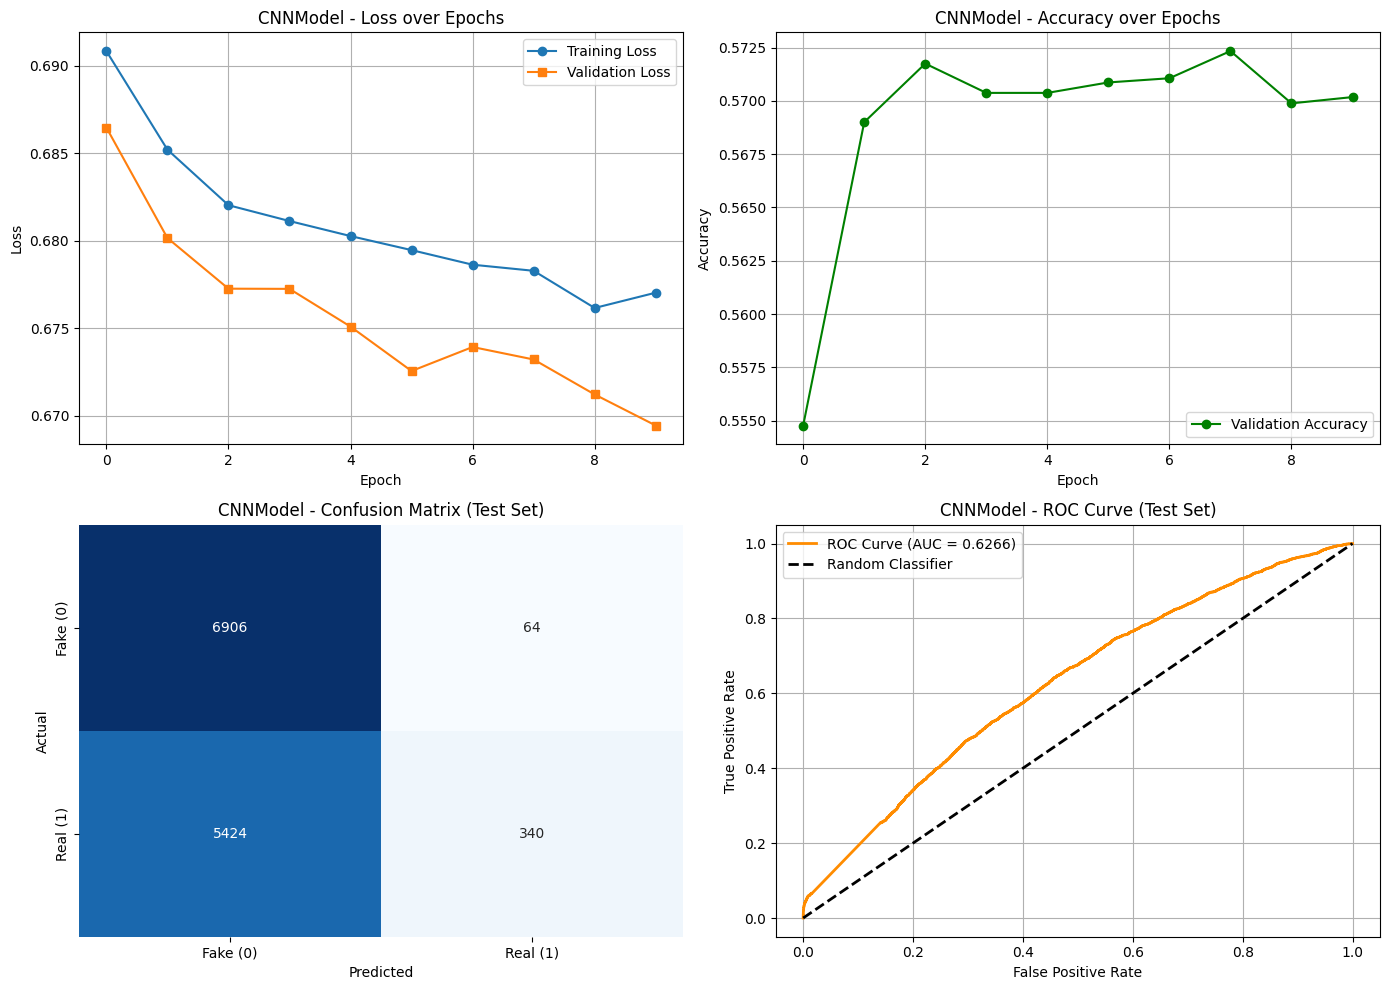


TRAINING LSTM MODEL
Training on device: cuda
Model: LSTMModel
Epoch [1/10] | Train Loss: 0.2895 | Val Loss: 0.2093 | Val Accuracy: 0.9136
Epoch [2/10] | Train Loss: 0.2199 | Val Loss: 0.1881 | Val Accuracy: 0.9237
Epoch [3/10] | Train Loss: 0.1998 | Val Loss: 0.1782 | Val Accuracy: 0.9278
Epoch [4/10] | Train Loss: 0.1856 | Val Loss: 0.1731 | Val Accuracy: 0.9291
Epoch [5/10] | Train Loss: 0.1725 | Val Loss: 0.1697 | Val Accuracy: 0.9332
Epoch [6/10] | Train Loss: 0.1635 | Val Loss: 0.1690 | Val Accuracy: 0.9334
Epoch [7/10] | Train Loss: 0.1551 | Val Loss: 0.1614 | Val Accuracy: 0.9391
Epoch [8/10] | Train Loss: 0.1490 | Val Loss: 0.1648 | Val Accuracy: 0.9392
Epoch [9/10] | Train Loss: 0.1394 | Val Loss: 0.1615 | Val Accuracy: 0.9360
Epoch [10/10] | Train Loss: 0.1363 | Val Loss: 0.1615 | Val Accuracy: 0.9397
LSTMModel training completed!

FINAL EVALUATION ON TEST SET - LSTMModel

Test Accuracy: 0.9310
Test AUC Score: 0.9808

Classification Report:
              precision    recall 

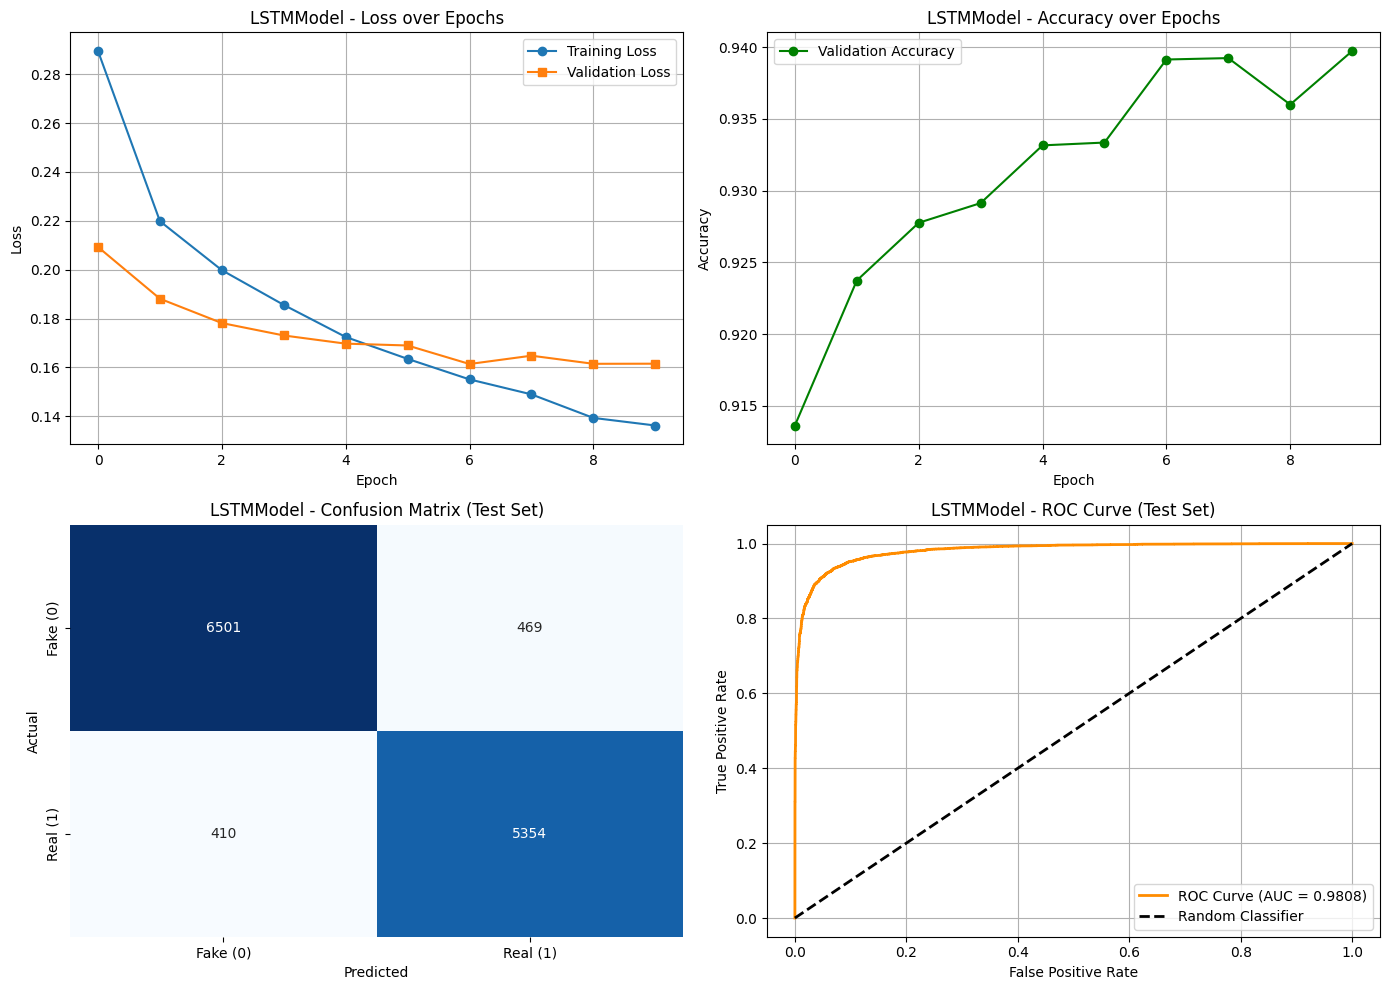


TRAINING CNN-LSTM HYBRID MODEL
Training on device: cuda
Model: CNNLSTMModel


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10] | Train Loss: 0.6896 | Val Loss: 0.6888 | Val Accuracy: 0.5461
Epoch [2/10] | Train Loss: 0.6893 | Val Loss: 0.6891 | Val Accuracy: 0.5461
Epoch [3/10] | Train Loss: 0.6889 | Val Loss: 0.6879 | Val Accuracy: 0.5461
Epoch [4/10] | Train Loss: 0.6856 | Val Loss: 0.6745 | Val Accuracy: 0.5855
Epoch [5/10] | Train Loss: 0.6714 | Val Loss: 0.6569 | Val Accuracy: 0.6169
Epoch [6/10] | Train Loss: 0.6572 | Val Loss: 0.6454 | Val Accuracy: 0.6265
Epoch [7/10] | Train Loss: 0.6521 | Val Loss: 0.6410 | Val Accuracy: 0.6308
Epoch [8/10] | Train Loss: 0.6478 | Val Loss: 0.6376 | Val Accuracy: 0.6347
Epoch [9/10] | Train Loss: 0.6452 | Val Loss: 0.6359 | Val Accuracy: 0.6416
Epoch [10/10] | Train Loss: 0.6426 | Val Loss: 0.6365 | Val Accuracy: 0.6318
CNNLSTMModel training completed!

FINAL EVALUATION ON TEST SET - CNNLSTMModel

Test Accuracy: 0.6344
Test AUC Score: 0.6776

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.62      0.86   

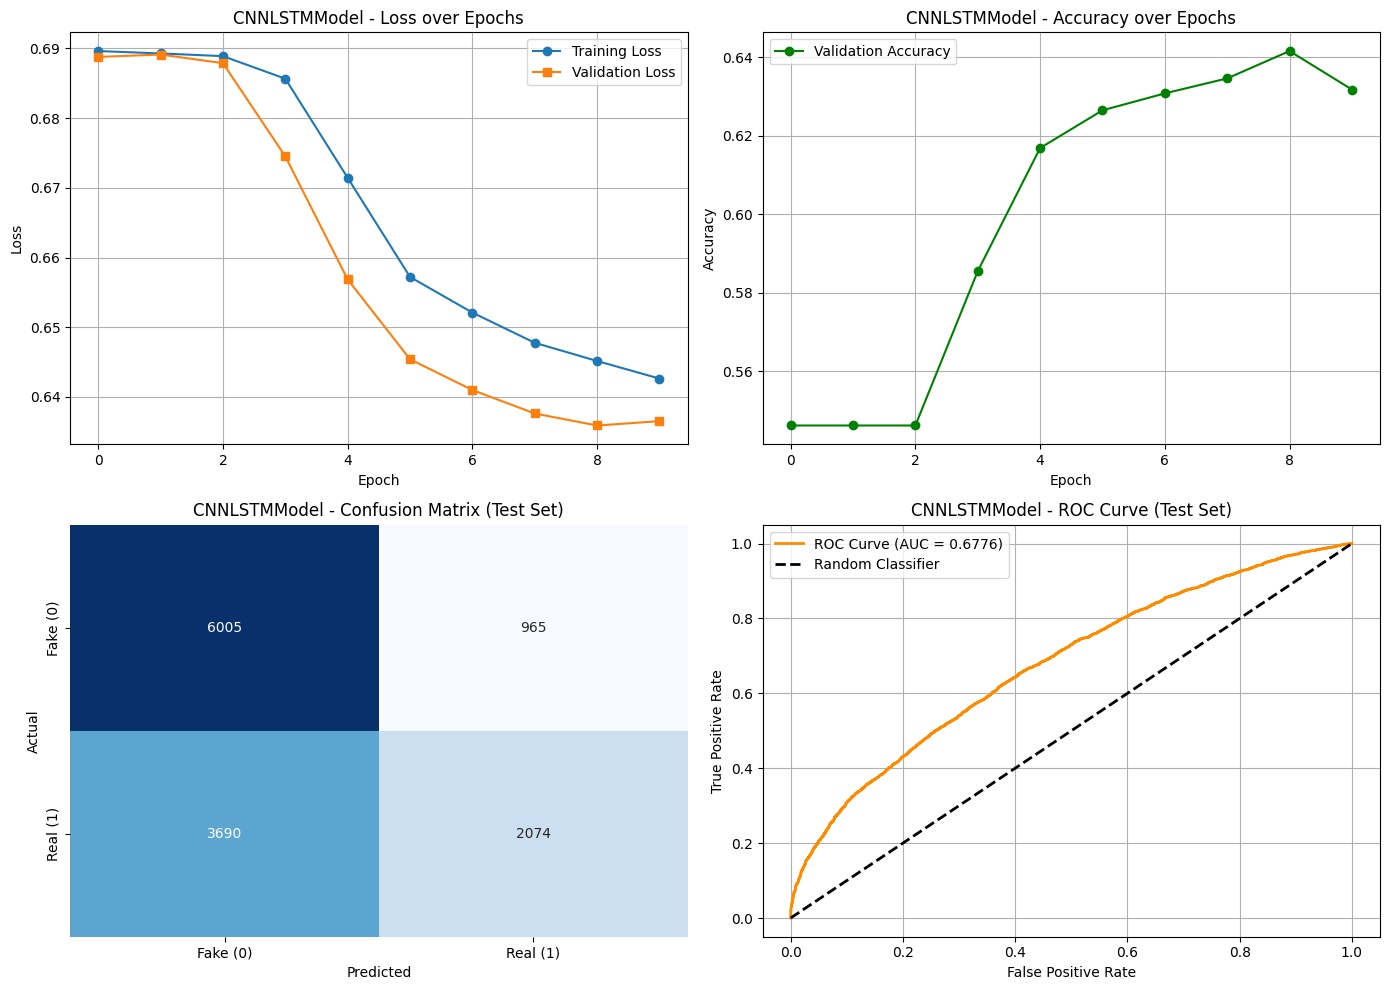


Pipeline completed successfully
GloVe embeddings generated: 300 dimensions
Training samples: 50936
Test samples: 12734
ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)
DL models trained (CNN, LSTM, CNN-LSTM)
  - CNN test accuracy: 0.5690
  - LSTM test accuracy: 0.9310
  - CNN-LSTM test accuracy: 0.6344



In [20]:
# Run full pipeline with defaults
glove_df, xtrain, ytrain, xtest, ytest, models_history = run_complete_pipeline(
    dataset_csv_path='/content/drive/MyDrive/datasets/WELFake_processed.csv',
    glove_file_path='/content/drive/MyDrive/datasets/dolma_300_2024_1.2M.100_combined.txt'
)


Starting complete GloVe + ML + DL pipeline

Step 1: Loading GloVe embeddings
--------------------------------------------------------------------------------
Loading GloVe embeddings from /content/drive/MyDrive/datasets/dolma_300_2024_1.2M.100_combined.txt...
Found 1200001 word vectors.

Step 2: Loading and processing dataset
--------------------------------------------------------------------------------
Detected embedding dimension: 300

Step 3: Generating averaged GloVe features
--------------------------------------------------------------------------------


Vectorizing texts: 100%|██████████| 39098/39098 [00:16<00:00, 2442.90it/s]


Saved GloVe features to preprocessed_datasets/glove_features_averaged.csv

Step 4: Splitting dataset (80/20 train/test)
--------------------------------------------------------------------------------
Total rows in dataset: 39098
Total rows in train set: 31278
Total rows in test set: 7820

Class distribution in full dataset:
label
0    21196
1    17902
Name: count, dtype: int64

Class distribution in train set:
label
0    16992
1    14286
Name: count, dtype: int64

Class distribution in test set:
label
0    4204
1    3616
Name: count, dtype: int64

 KNN 


Step 5: Training traditional ML models
--------------------------------------------------------------------------------

 KNN 

              precision    recall  f1-score   support

           0       0.90      0.97      0.93      4204
           1       0.96      0.88      0.92      3616

    accuracy                           0.93      7820
   macro avg       0.93      0.92      0.93      7820
weighted avg       0.93      0.93    

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:41:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.95      0.98      0.96      4204
           1       0.97      0.94      0.96      3616

    accuracy                           0.96      7820
   macro avg       0.96      0.96      0.96      7820
weighted avg       0.96      0.96      0.96      7820


 Random Forest Classifier 

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      4204
           1       0.95      0.90      0.92      3616

    accuracy                           0.93      7820
   macro avg       0.93      0.93      0.93      7820
weighted avg       0.93      0.93      0.93      7820


Step 6: Training deep learning models with validation/test split
--------------------------------------------------------------------------------
DATA SPLIT VERIFICATION
Training set size: 31278
Test set size: 7820
Validation split: 20.0%
Effective training size: 25022
Effective validation size: 6255
✓ Test set wil

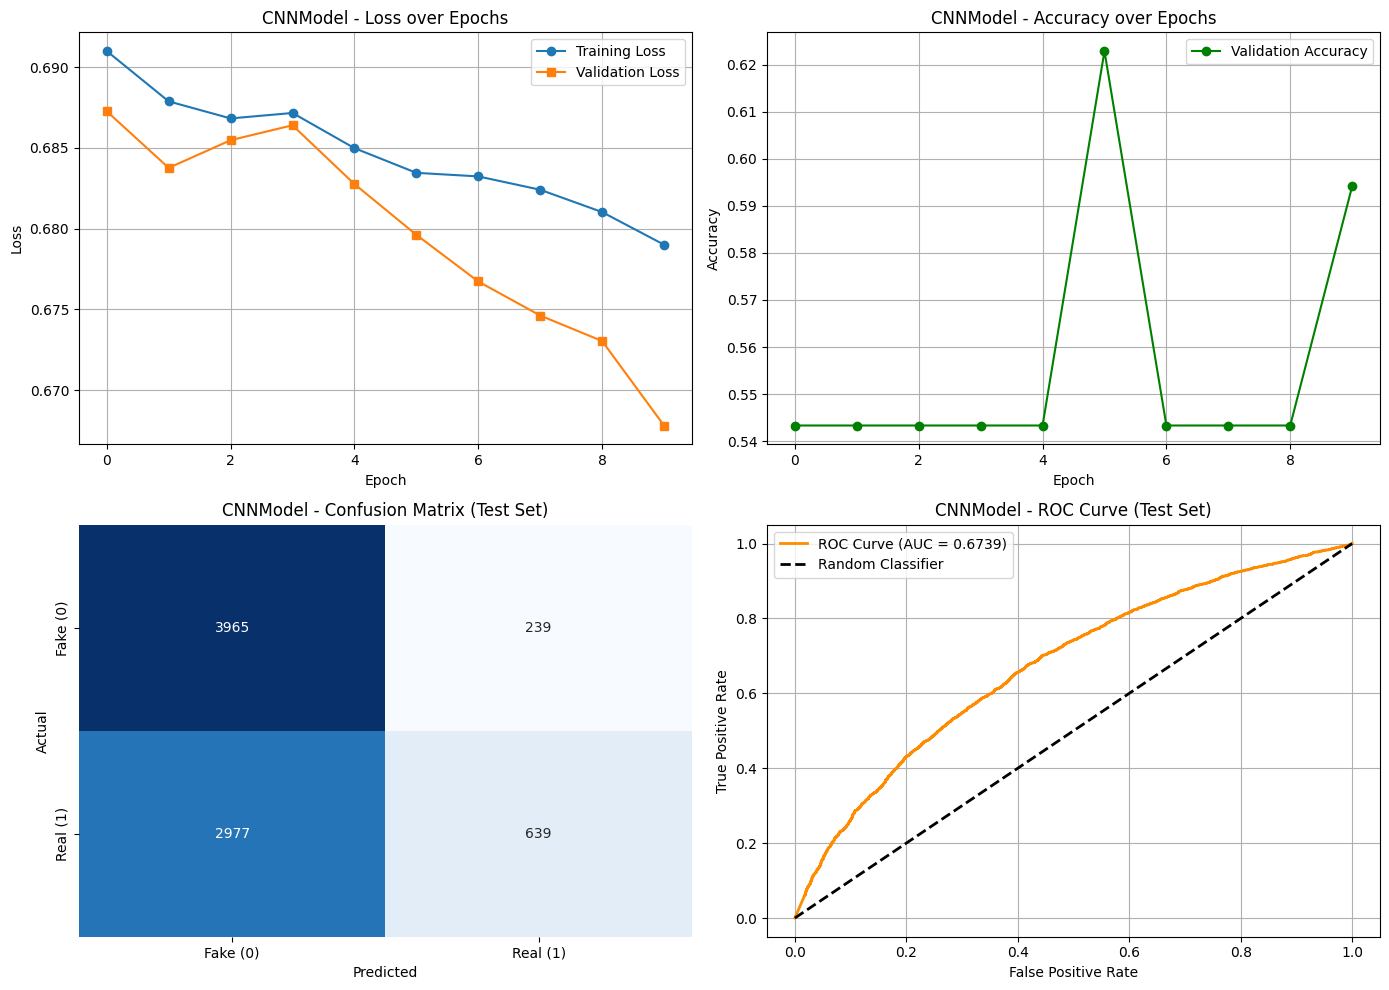


TRAINING LSTM MODEL
Training on device: cuda
Model: LSTMModel
Epoch [1/10] | Train Loss: 0.1546 | Val Loss: 0.0845 | Val Accuracy: 0.9703
Epoch [2/10] | Train Loss: 0.0858 | Val Loss: 0.0694 | Val Accuracy: 0.9733
Epoch [3/10] | Train Loss: 0.0695 | Val Loss: 0.0637 | Val Accuracy: 0.9776
Epoch [4/10] | Train Loss: 0.0598 | Val Loss: 0.0655 | Val Accuracy: 0.9770
Epoch [5/10] | Train Loss: 0.0552 | Val Loss: 0.0639 | Val Accuracy: 0.9776
Epoch [6/10] | Train Loss: 0.0513 | Val Loss: 0.0598 | Val Accuracy: 0.9795
Epoch [7/10] | Train Loss: 0.0437 | Val Loss: 0.0615 | Val Accuracy: 0.9791
Epoch [8/10] | Train Loss: 0.0409 | Val Loss: 0.0633 | Val Accuracy: 0.9789
Epoch [9/10] | Train Loss: 0.0411 | Val Loss: 0.0580 | Val Accuracy: 0.9789
Epoch [10/10] | Train Loss: 0.0373 | Val Loss: 0.0600 | Val Accuracy: 0.9802
LSTMModel training completed!

FINAL EVALUATION ON TEST SET - LSTMModel

Test Accuracy: 0.9763
Test AUC Score: 0.9968

Classification Report:
              precision    recall 

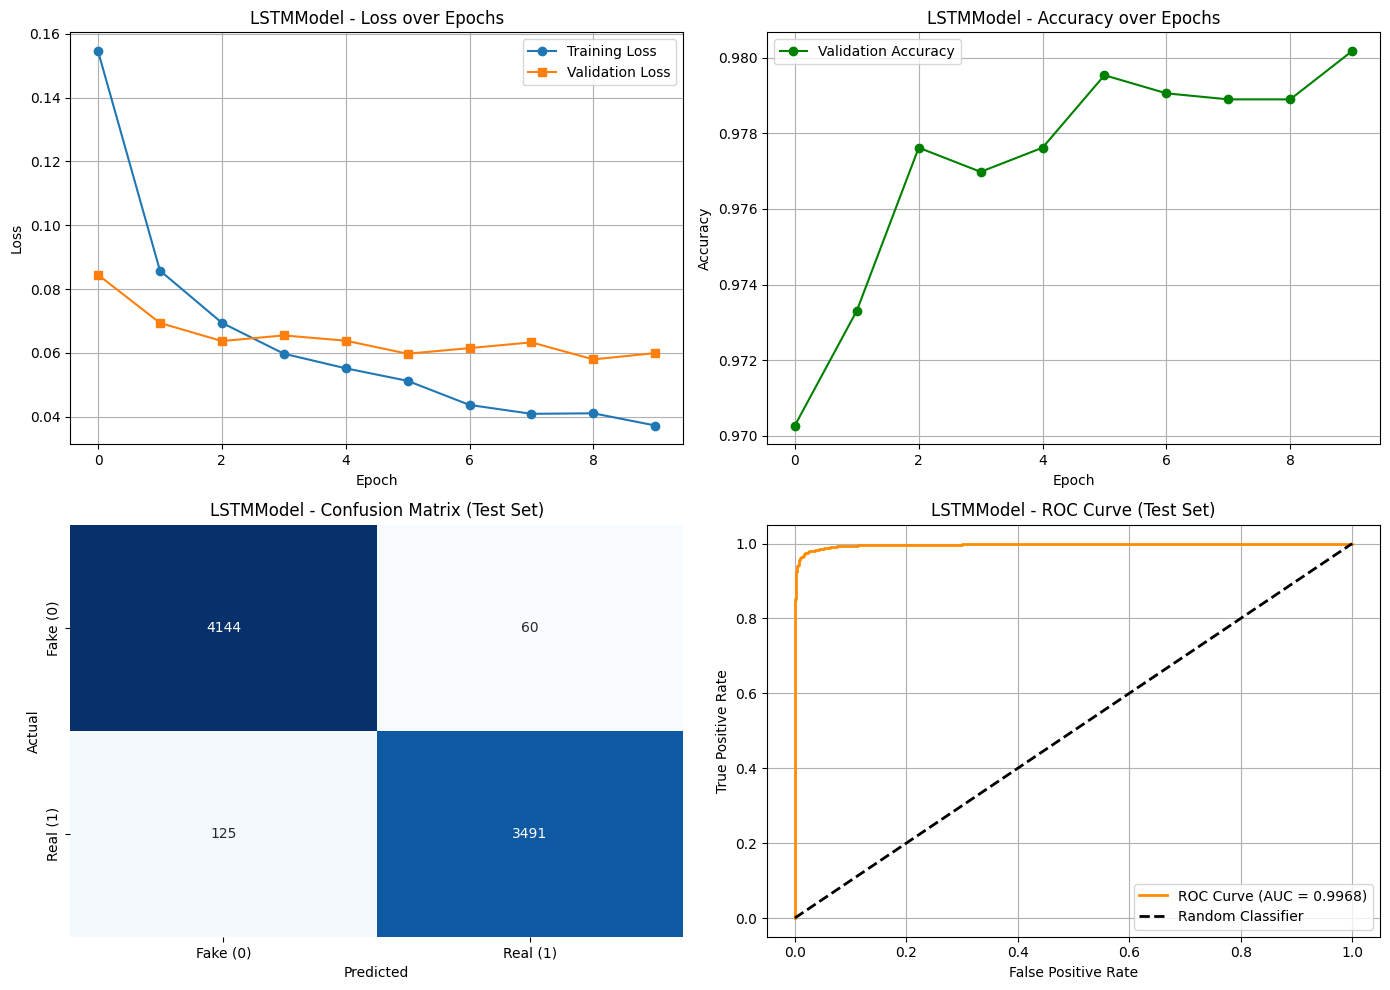


TRAINING CNN-LSTM HYBRID MODEL
Training on device: cuda
Model: CNNLSTMModel


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10] | Train Loss: 0.6789 | Val Loss: 0.6599 | Val Accuracy: 0.6060
Epoch [2/10] | Train Loss: 0.6592 | Val Loss: 0.6532 | Val Accuracy: 0.6282
Epoch [3/10] | Train Loss: 0.6487 | Val Loss: 0.6338 | Val Accuracy: 0.6453
Epoch [4/10] | Train Loss: 0.6393 | Val Loss: 0.6223 | Val Accuracy: 0.6606
Epoch [5/10] | Train Loss: 0.6320 | Val Loss: 0.6150 | Val Accuracy: 0.6618
Epoch [6/10] | Train Loss: 0.6232 | Val Loss: 0.6337 | Val Accuracy: 0.6419
Epoch [7/10] | Train Loss: 0.6227 | Val Loss: 0.6112 | Val Accuracy: 0.6666
Epoch [8/10] | Train Loss: 0.6164 | Val Loss: 0.6010 | Val Accuracy: 0.6728
Epoch [9/10] | Train Loss: 0.6156 | Val Loss: 0.5999 | Val Accuracy: 0.6706
Epoch [10/10] | Train Loss: 0.6099 | Val Loss: 0.6029 | Val Accuracy: 0.6762
CNNLSTMModel training completed!

FINAL EVALUATION ON TEST SET - CNNLSTMModel

Test Accuracy: 0.6758
Test AUC Score: 0.7266

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.67      0.78   

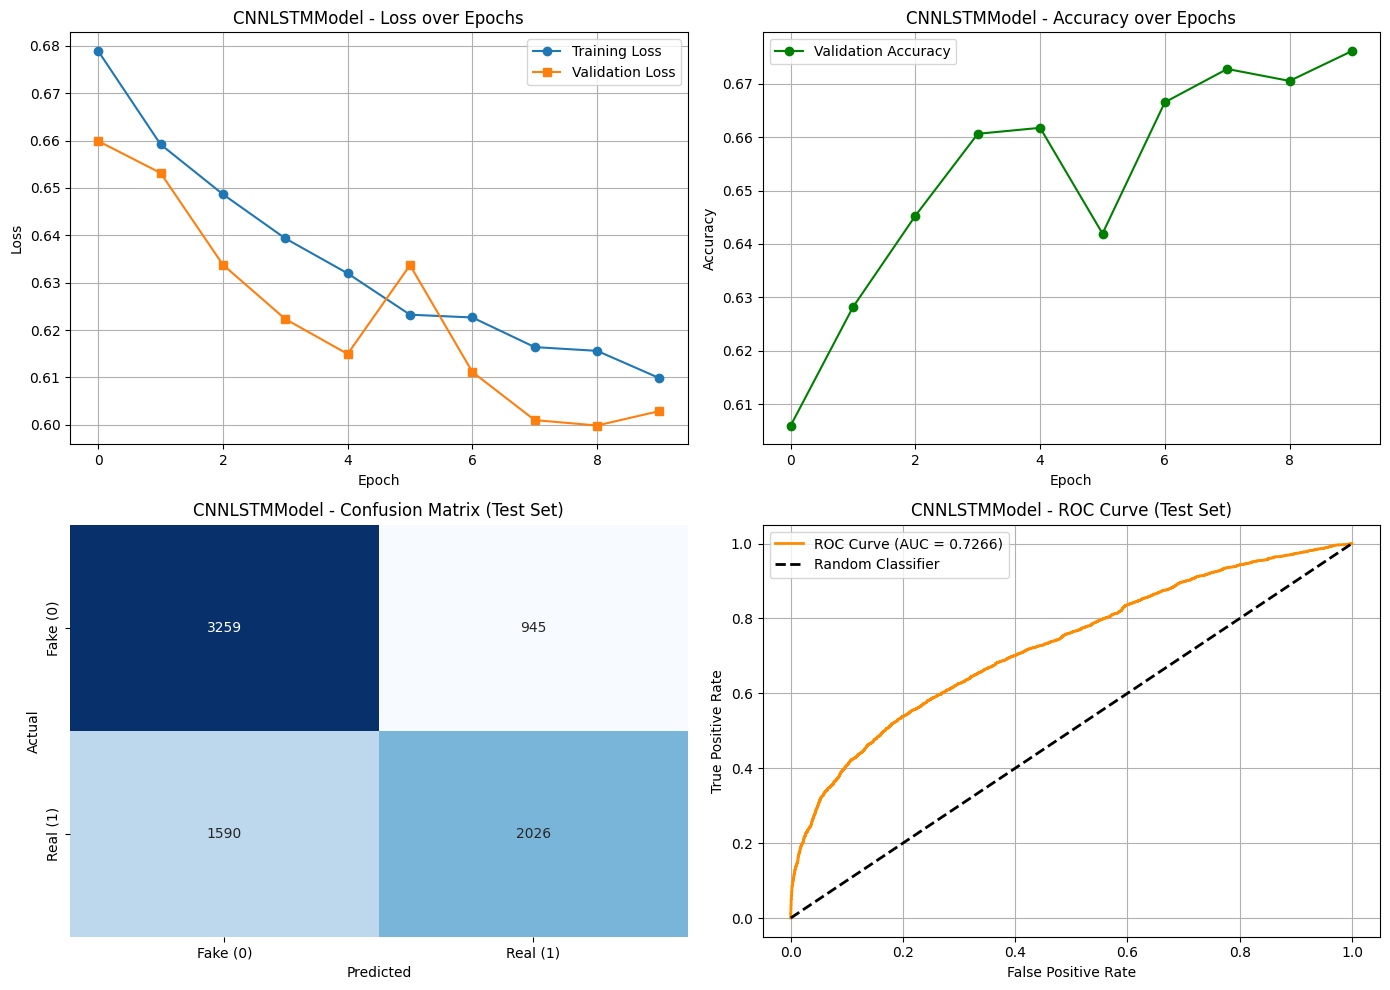


Pipeline completed successfully
GloVe embeddings generated: 300 dimensions
Training samples: 31278
Test samples: 7820
ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)
DL models trained (CNN, LSTM, CNN-LSTM)
  - CNN test accuracy: 0.5887
  - LSTM test accuracy: 0.9763
  - CNN-LSTM test accuracy: 0.6758



In [21]:
#ISOT
glove_df, xtrain, ytrain, xtest, ytest, models_history = run_complete_pipeline(
    dataset_csv_path='/content/drive/MyDrive/datasets/ISOT_processed.csv',
    glove_file_path='/content/drive/MyDrive/datasets/dolma_300_2024_1.2M.100_combined.txt'
)


Starting complete GloVe + ML + DL pipeline

Step 1: Loading GloVe embeddings
--------------------------------------------------------------------------------
Loading GloVe embeddings from /content/drive/MyDrive/datasets/dolma_300_2024_1.2M.100_combined.txt...
Found 1200001 word vectors.

Step 2: Loading and processing dataset
--------------------------------------------------------------------------------
Detected embedding dimension: 300

Step 3: Generating averaged GloVe features
--------------------------------------------------------------------------------


Vectorizing texts: 100%|██████████| 38650/38650 [00:16<00:00, 2378.30it/s]


Saved GloVe features to preprocessed_datasets/glove_features_averaged.csv

Step 4: Splitting dataset (80/20 train/test)
--------------------------------------------------------------------------------
Total rows in dataset: 38650
Total rows in train set: 30920
Total rows in test set: 7730

Class distribution in full dataset:
label
1    21194
0    17456
Name: count, dtype: int64

Class distribution in train set:
label
1    16971
0    13949
Name: count, dtype: int64

Class distribution in test set:
label
1    4223
0    3507
Name: count, dtype: int64

 KNN 


Step 5: Training traditional ML models
--------------------------------------------------------------------------------

 KNN 

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      3507
           1       0.91      0.97      0.94      4223

    accuracy                           0.93      7730
   macro avg       0.93      0.93      0.93      7730
weighted avg       0.93      0.93    

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:50:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.97      0.95      0.96      3507
           1       0.96      0.97      0.97      4223

    accuracy                           0.96      7730
   macro avg       0.96      0.96      0.96      7730
weighted avg       0.96      0.96      0.96      7730


 Random Forest Classifier 

              precision    recall  f1-score   support

           0       0.94      0.91      0.93      3507
           1       0.93      0.96      0.94      4223

    accuracy                           0.94      7730
   macro avg       0.94      0.93      0.93      7730
weighted avg       0.94      0.94      0.93      7730


Step 6: Training deep learning models with validation/test split
--------------------------------------------------------------------------------
DATA SPLIT VERIFICATION
Training set size: 30920
Test set size: 7730
Validation split: 20.0%
Effective training size: 24736
Effective validation size: 6184
✓ Test set wil

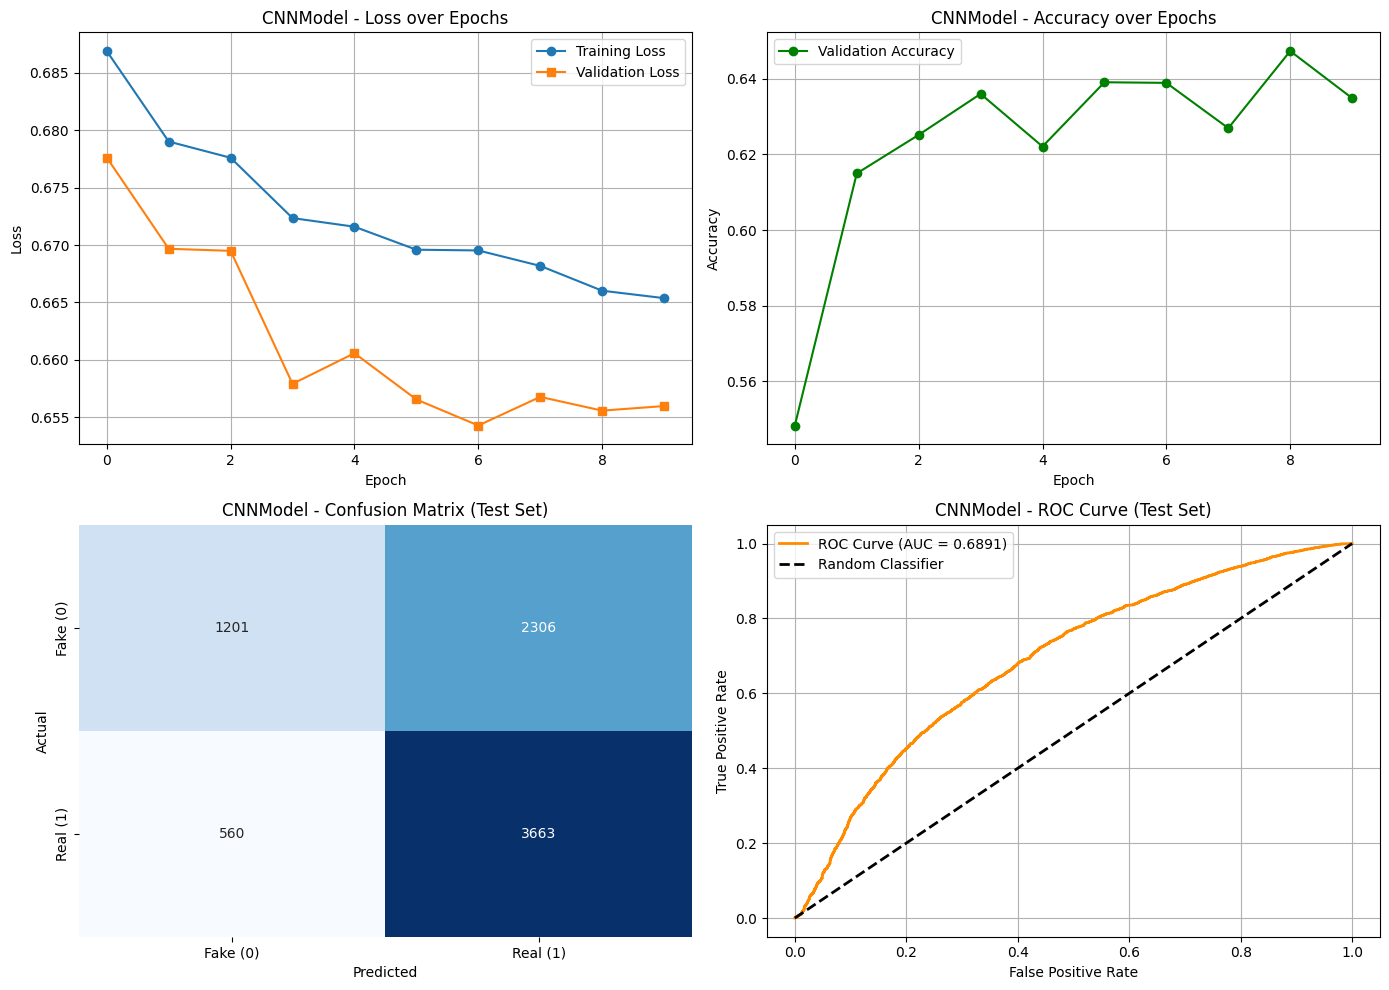


TRAINING LSTM MODEL
Training on device: cuda
Model: LSTMModel
Epoch [1/10] | Train Loss: 0.1550 | Val Loss: 0.0824 | Val Accuracy: 0.9696
Epoch [2/10] | Train Loss: 0.0869 | Val Loss: 0.0744 | Val Accuracy: 0.9754
Epoch [3/10] | Train Loss: 0.0739 | Val Loss: 0.0657 | Val Accuracy: 0.9759
Epoch [4/10] | Train Loss: 0.0632 | Val Loss: 0.0660 | Val Accuracy: 0.9761
Epoch [5/10] | Train Loss: 0.0589 | Val Loss: 0.0644 | Val Accuracy: 0.9775
Epoch [6/10] | Train Loss: 0.0518 | Val Loss: 0.0683 | Val Accuracy: 0.9775
Epoch [7/10] | Train Loss: 0.0460 | Val Loss: 0.0667 | Val Accuracy: 0.9761
Epoch [8/10] | Train Loss: 0.0426 | Val Loss: 0.0689 | Val Accuracy: 0.9769
Epoch [9/10] | Train Loss: 0.0419 | Val Loss: 0.0688 | Val Accuracy: 0.9791
Epoch [10/10] | Train Loss: 0.0389 | Val Loss: 0.0719 | Val Accuracy: 0.9766
LSTMModel training completed!

FINAL EVALUATION ON TEST SET - LSTMModel

Test Accuracy: 0.9770
Test AUC Score: 0.9967

Classification Report:
              precision    recall 

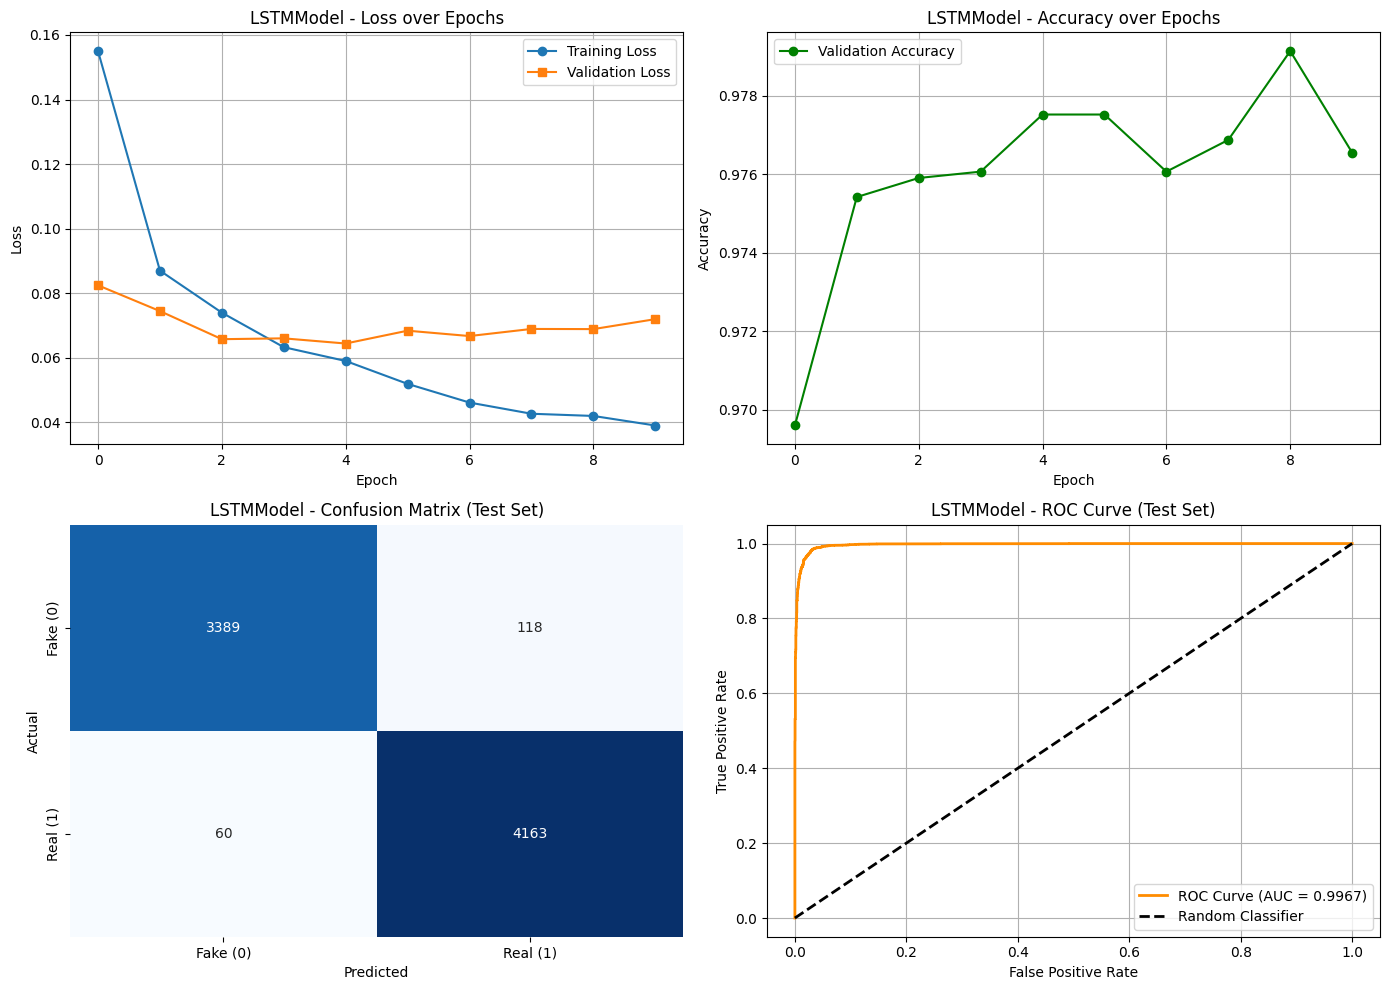


TRAINING CNN-LSTM HYBRID MODEL
Training on device: cuda
Model: CNNLSTMModel


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10] | Train Loss: 0.6750 | Val Loss: 0.6564 | Val Accuracy: 0.6195
Epoch [2/10] | Train Loss: 0.6594 | Val Loss: 0.6505 | Val Accuracy: 0.6216
Epoch [3/10] | Train Loss: 0.6510 | Val Loss: 0.6454 | Val Accuracy: 0.6462
Epoch [4/10] | Train Loss: 0.6414 | Val Loss: 0.6247 | Val Accuracy: 0.6606
Epoch [5/10] | Train Loss: 0.6303 | Val Loss: 0.6451 | Val Accuracy: 0.6274
Epoch [6/10] | Train Loss: 0.6243 | Val Loss: 0.6206 | Val Accuracy: 0.6549
Epoch [7/10] | Train Loss: 0.6205 | Val Loss: 0.6045 | Val Accuracy: 0.6800
Epoch [8/10] | Train Loss: 0.6164 | Val Loss: 0.6252 | Val Accuracy: 0.6480
Epoch [9/10] | Train Loss: 0.6091 | Val Loss: 0.5991 | Val Accuracy: 0.6811
Epoch [10/10] | Train Loss: 0.6061 | Val Loss: 0.6110 | Val Accuracy: 0.6658
CNNLSTMModel training completed!

FINAL EVALUATION ON TEST SET - CNNLSTMModel

Test Accuracy: 0.6561
Test AUC Score: 0.7335

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.81      0.32   

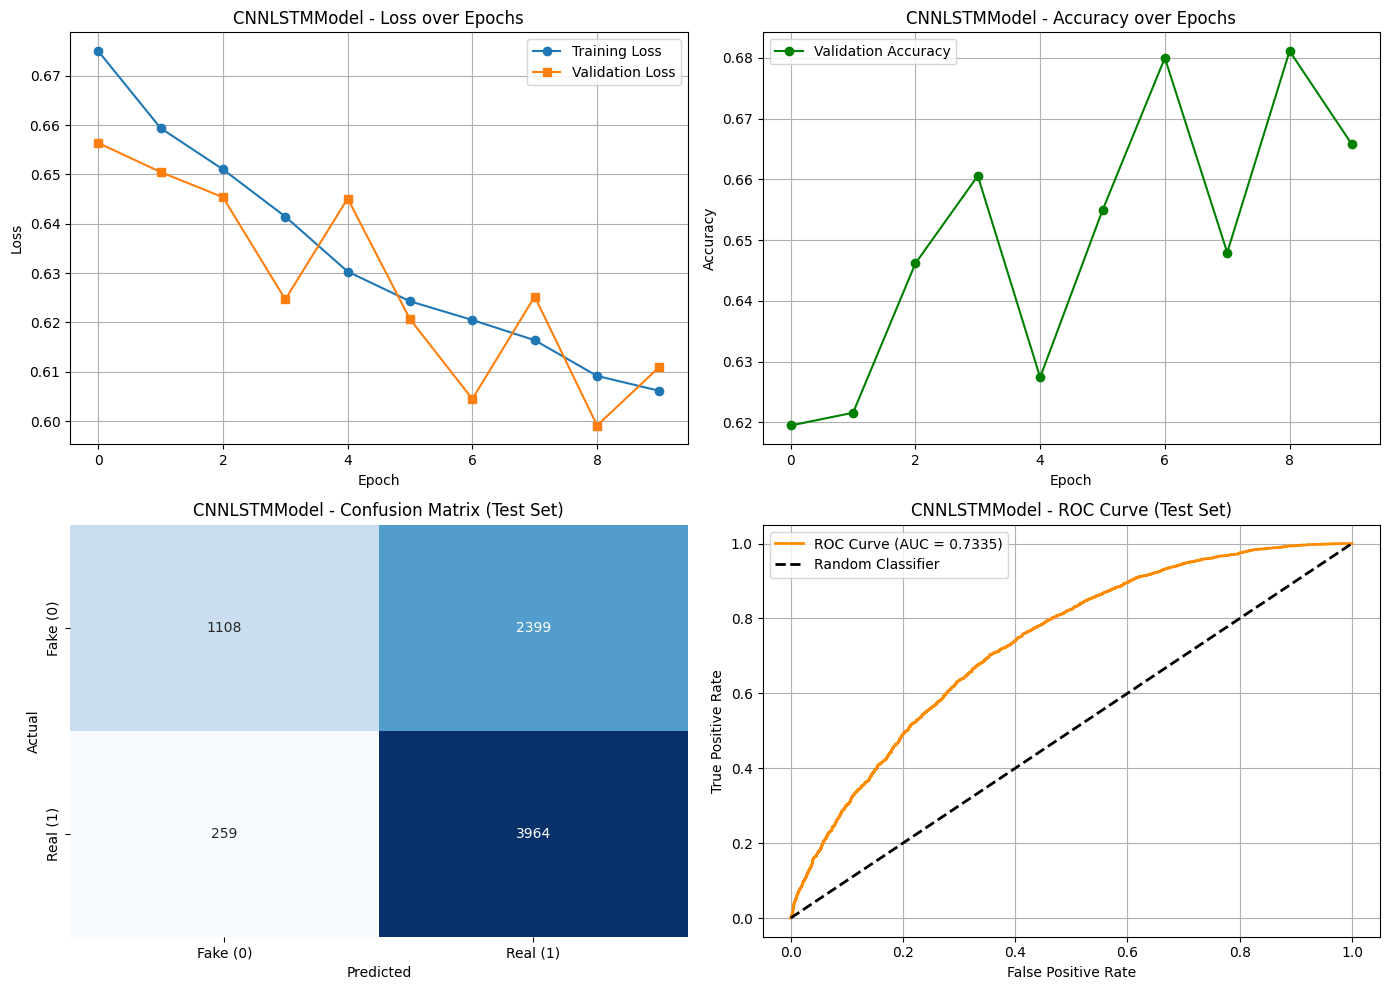


Pipeline completed successfully
GloVe embeddings generated: 300 dimensions
Training samples: 30920
Test samples: 7730
ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)
DL models trained (CNN, LSTM, CNN-LSTM)
  - CNN test accuracy: 0.6292
  - LSTM test accuracy: 0.9770
  - CNN-LSTM test accuracy: 0.6561



In [22]:
#Fake_News_Detection
glove_df, xtrain, ytrain, xtest, ytest, models_history = run_complete_pipeline(
    dataset_csv_path='/content/drive/MyDrive/datasets/Fake_News_Detection_processed.csv',
    glove_file_path='/content/drive/MyDrive/datasets/dolma_300_2024_1.2M.100_combined.txt'
)


Starting complete GloVe + ML + DL pipeline

Step 1: Loading GloVe embeddings
--------------------------------------------------------------------------------
Loading GloVe embeddings from /content/drive/MyDrive/datasets/dolma_300_2024_1.2M.100_combined.txt...
Found 1200001 word vectors.

Step 2: Loading and processing dataset
--------------------------------------------------------------------------------
Detected embedding dimension: 300

Step 3: Generating averaged GloVe features
--------------------------------------------------------------------------------


Vectorizing texts: 100%|██████████| 40580/40580 [00:17<00:00, 2336.59it/s]


Saved GloVe features to preprocessed_datasets/glove_features_averaged.csv

Step 4: Splitting dataset (80/20 train/test)
--------------------------------------------------------------------------------
Total rows in dataset: 40580
Total rows in train set: 32464
Total rows in test set: 8116

Class distribution in full dataset:
label
1    21923
0    18657
Name: count, dtype: int64

Class distribution in train set:
label
1    17495
0    14969
Name: count, dtype: int64

Class distribution in test set:
label
1    4428
0    3688
Name: count, dtype: int64

 KNN 


Step 5: Training traditional ML models
--------------------------------------------------------------------------------

 KNN 

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      3688
           1       0.91      0.94      0.93      4428

    accuracy                           0.92      8116
   macro avg       0.92      0.92      0.92      8116
weighted avg       0.92      0.92    

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:58:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.94      0.95      0.95      3688
           1       0.96      0.95      0.95      4428

    accuracy                           0.95      8116
   macro avg       0.95      0.95      0.95      8116
weighted avg       0.95      0.95      0.95      8116


 Random Forest Classifier 

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      3688
           1       0.93      0.93      0.93      4428

    accuracy                           0.92      8116
   macro avg       0.92      0.92      0.92      8116
weighted avg       0.92      0.92      0.92      8116


Step 6: Training deep learning models with validation/test split
--------------------------------------------------------------------------------
DATA SPLIT VERIFICATION
Training set size: 32464
Test set size: 8116
Validation split: 20.0%
Effective training size: 25971
Effective validation size: 6492
✓ Test set wil

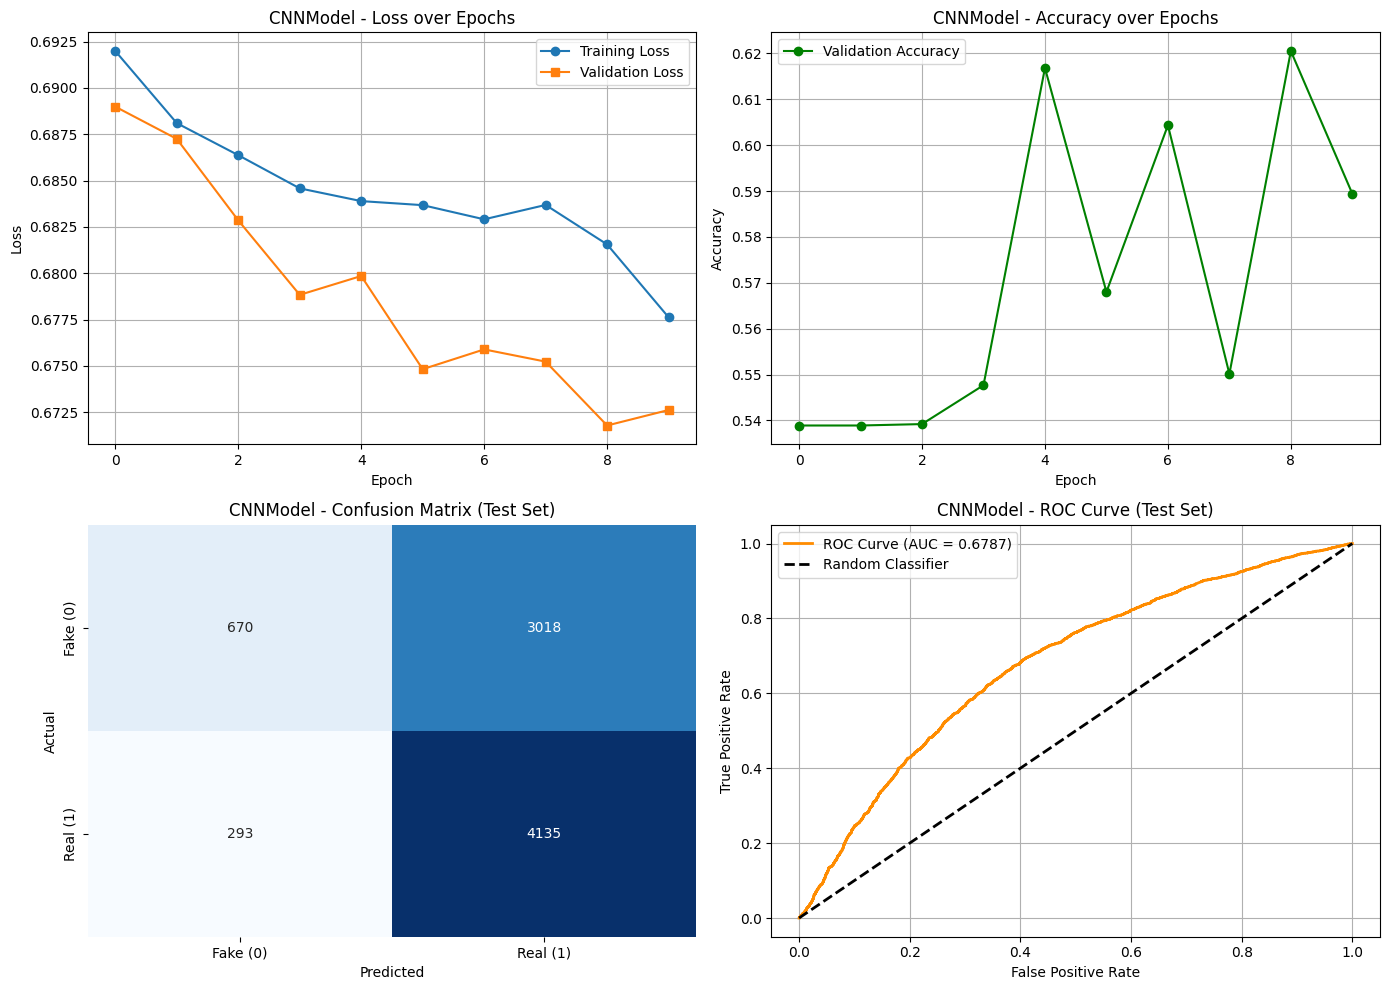


TRAINING LSTM MODEL
Training on device: cuda
Model: LSTMModel
Epoch [1/10] | Train Loss: 0.1945 | Val Loss: 0.1193 | Val Accuracy: 0.9564
Epoch [2/10] | Train Loss: 0.1267 | Val Loss: 0.1029 | Val Accuracy: 0.9615
Epoch [3/10] | Train Loss: 0.1057 | Val Loss: 0.0951 | Val Accuracy: 0.9641
Epoch [4/10] | Train Loss: 0.1005 | Val Loss: 0.0944 | Val Accuracy: 0.9670
Epoch [5/10] | Train Loss: 0.0900 | Val Loss: 0.0930 | Val Accuracy: 0.9669
Epoch [6/10] | Train Loss: 0.0825 | Val Loss: 0.0915 | Val Accuracy: 0.9664
Epoch [7/10] | Train Loss: 0.0772 | Val Loss: 0.0960 | Val Accuracy: 0.9663
Epoch [8/10] | Train Loss: 0.0744 | Val Loss: 0.0912 | Val Accuracy: 0.9678
Epoch [9/10] | Train Loss: 0.0683 | Val Loss: 0.1004 | Val Accuracy: 0.9681
Epoch [10/10] | Train Loss: 0.0662 | Val Loss: 0.0938 | Val Accuracy: 0.9675
LSTMModel training completed!

FINAL EVALUATION ON TEST SET - LSTMModel

Test Accuracy: 0.9614
Test AUC Score: 0.9937

Classification Report:
              precision    recall 

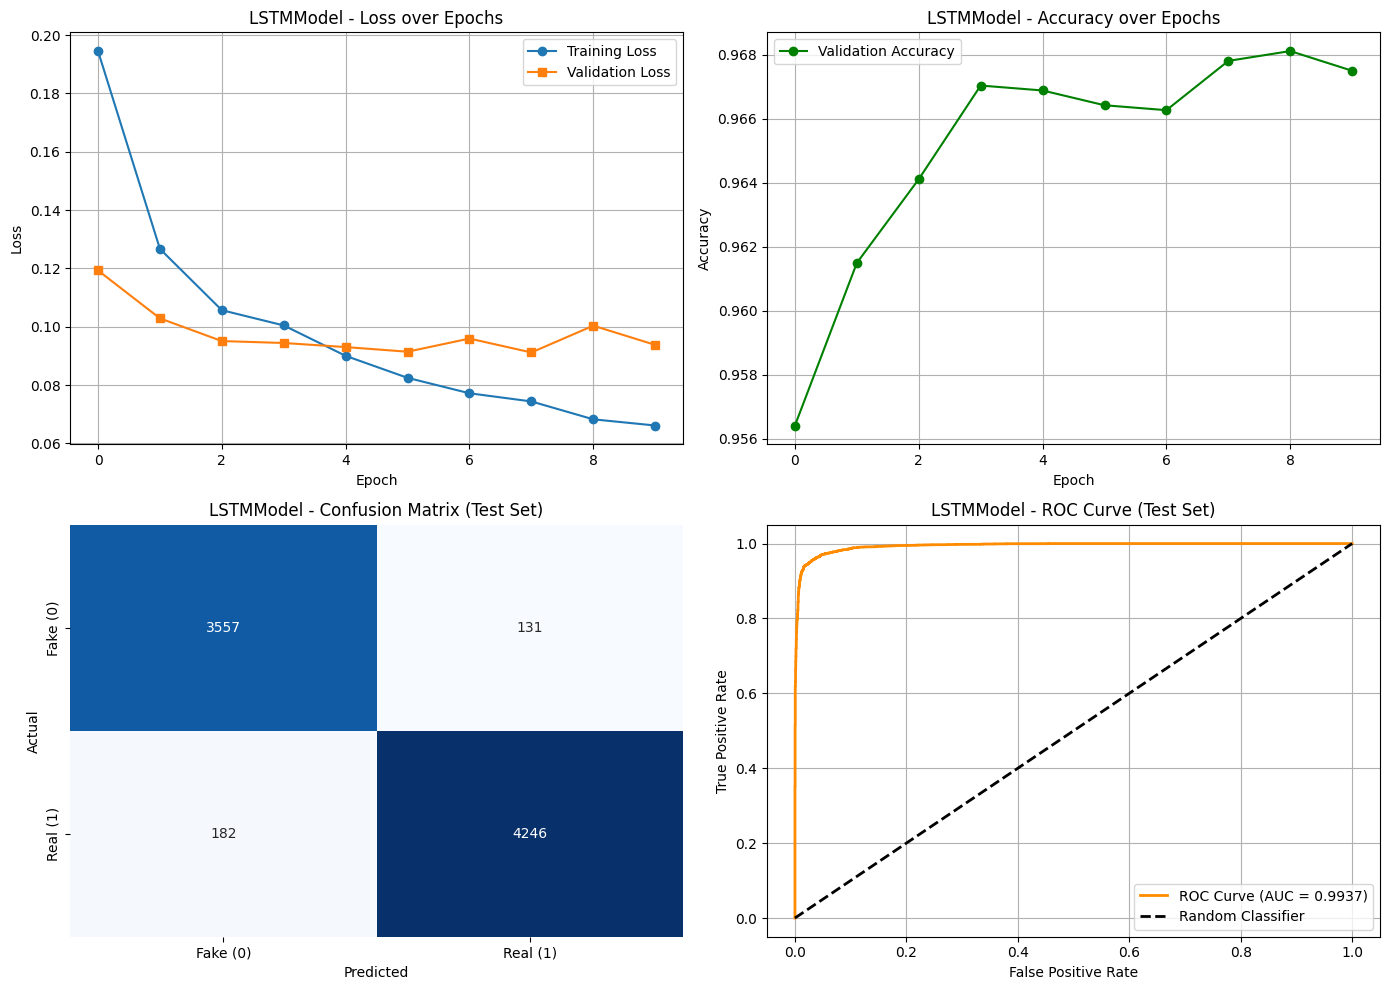


TRAINING CNN-LSTM HYBRID MODEL
Training on device: cuda
Model: CNNLSTMModel


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10] | Train Loss: 0.6784 | Val Loss: 0.6644 | Val Accuracy: 0.6128
Epoch [2/10] | Train Loss: 0.6649 | Val Loss: 0.6624 | Val Accuracy: 0.6023
Epoch [3/10] | Train Loss: 0.6599 | Val Loss: 0.6514 | Val Accuracy: 0.6245
Epoch [4/10] | Train Loss: 0.6498 | Val Loss: 0.6412 | Val Accuracy: 0.6339
Epoch [5/10] | Train Loss: 0.6420 | Val Loss: 0.6417 | Val Accuracy: 0.6393
Epoch [6/10] | Train Loss: 0.6333 | Val Loss: 0.6215 | Val Accuracy: 0.6519
Epoch [7/10] | Train Loss: 0.6296 | Val Loss: 0.6351 | Val Accuracy: 0.6368
Epoch [8/10] | Train Loss: 0.6223 | Val Loss: 0.6204 | Val Accuracy: 0.6553
Epoch [9/10] | Train Loss: 0.6210 | Val Loss: 0.6114 | Val Accuracy: 0.6595
Epoch [10/10] | Train Loss: 0.6177 | Val Loss: 0.6088 | Val Accuracy: 0.6582
CNNLSTMModel training completed!

FINAL EVALUATION ON TEST SET - CNNLSTMModel

Test Accuracy: 0.6804
Test AUC Score: 0.7327

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.67      0.59   

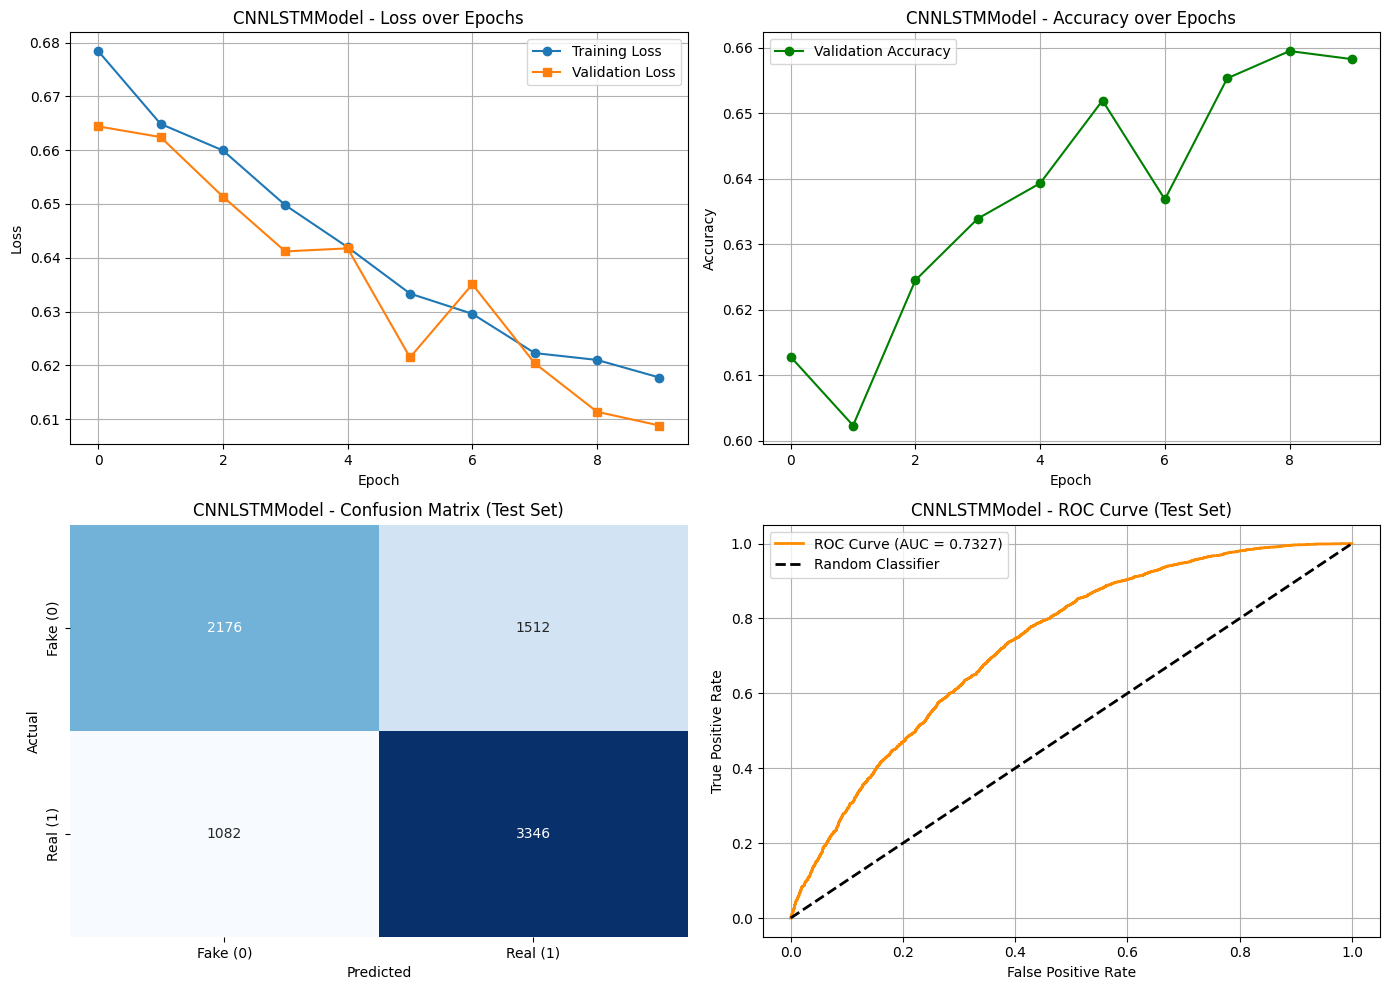


Pipeline completed successfully
GloVe embeddings generated: 300 dimensions
Training samples: 32464
Test samples: 8116
ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)
DL models trained (CNN, LSTM, CNN-LSTM)
  - CNN test accuracy: 0.5920
  - LSTM test accuracy: 0.9614
  - CNN-LSTM test accuracy: 0.6804



In [23]:
#Fake_News_Classification

glove_df, xtrain, ytrain, xtest, ytest, models_history = run_complete_pipeline(
    dataset_csv_path='/content/drive/MyDrive/datasets/Fake_News_Classification_processed.csv',
    glove_file_path='/content/drive/MyDrive/datasets/dolma_300_2024_1.2M.100_combined.txt'
)


Starting complete GloVe + ML + DL pipeline

Step 1: Loading GloVe embeddings
--------------------------------------------------------------------------------
Loading GloVe embeddings from /content/drive/MyDrive/datasets/dolma_300_2024_1.2M.100_combined.txt...
Found 1200001 word vectors.

Step 2: Loading and processing dataset
--------------------------------------------------------------------------------
Detected embedding dimension: 300

Step 3: Generating averaged GloVe features
--------------------------------------------------------------------------------


Vectorizing texts: 100%|██████████| 21844/21844 [00:00<00:00, 30673.86it/s]


Saved GloVe features to preprocessed_datasets/glove_features_averaged.csv

Step 4: Splitting dataset (80/20 train/test)
--------------------------------------------------------------------------------
Total rows in dataset: 21844
Total rows in train set: 17475
Total rows in test set: 4369

Class distribution in full dataset:
label
1    16522
0     5322
Name: count, dtype: int64

Class distribution in train set:
label
1    13182
0     4293
Name: count, dtype: int64

Class distribution in test set:
label
1    3340
0    1029
Name: count, dtype: int64

 KNN 


Step 5: Training traditional ML models
--------------------------------------------------------------------------------

 KNN 

              precision    recall  f1-score   support

           0       0.60      0.49      0.54      1029
           1       0.85      0.90      0.88      3340

    accuracy                           0.80      4369
   macro avg       0.73      0.70      0.71      4369
weighted avg       0.79      0.80    

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:06:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.63      0.42      0.50      1029
           1       0.84      0.92      0.88      3340

    accuracy                           0.81      4369
   macro avg       0.73      0.67      0.69      4369
weighted avg       0.79      0.81      0.79      4369


 Random Forest Classifier 

              precision    recall  f1-score   support

           0       0.64      0.21      0.32      1029
           1       0.80      0.96      0.87      3340

    accuracy                           0.79      4369
   macro avg       0.72      0.59      0.60      4369
weighted avg       0.76      0.79      0.74      4369


Step 6: Training deep learning models with validation/test split
--------------------------------------------------------------------------------
DATA SPLIT VERIFICATION
Training set size: 17475
Test set size: 4369
Validation split: 20.0%
Effective training size: 13980
Effective validation size: 3495
✓ Test set wil

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


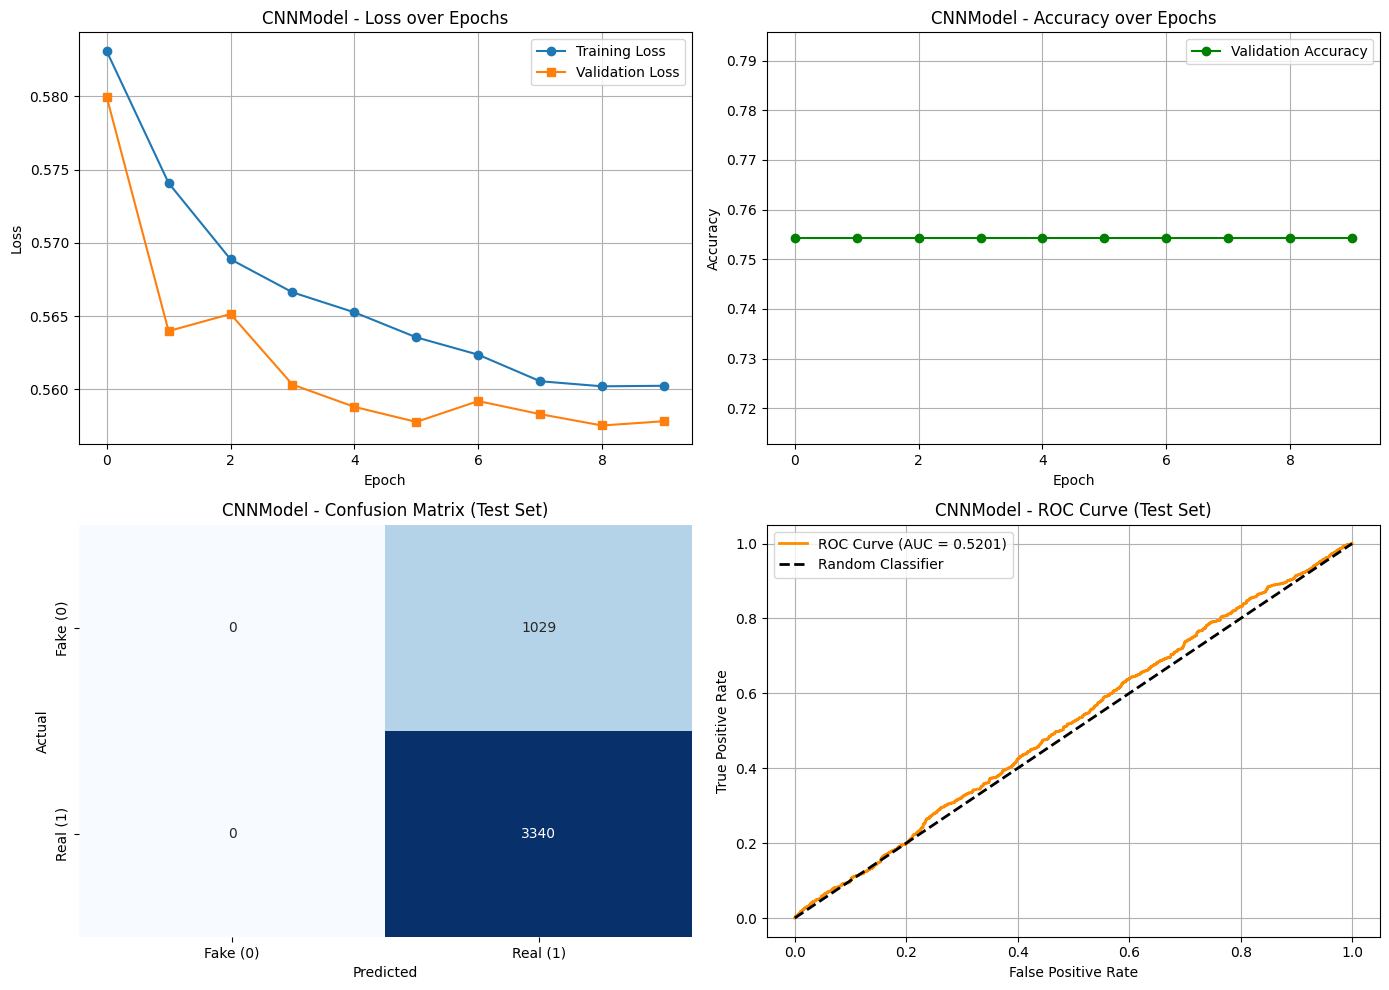


TRAINING LSTM MODEL
Training on device: cuda
Model: LSTMModel
Epoch [1/10] | Train Loss: 0.4735 | Val Loss: 0.4111 | Val Accuracy: 0.8212
Epoch [2/10] | Train Loss: 0.4032 | Val Loss: 0.4013 | Val Accuracy: 0.8260
Epoch [3/10] | Train Loss: 0.3699 | Val Loss: 0.4026 | Val Accuracy: 0.8306
Epoch [4/10] | Train Loss: 0.3468 | Val Loss: 0.4016 | Val Accuracy: 0.8363
Epoch [5/10] | Train Loss: 0.3177 | Val Loss: 0.4142 | Val Accuracy: 0.8298
Epoch [6/10] | Train Loss: 0.2938 | Val Loss: 0.4280 | Val Accuracy: 0.8237
Epoch [7/10] | Train Loss: 0.2748 | Val Loss: 0.4467 | Val Accuracy: 0.8229
Epoch [8/10] | Train Loss: 0.2605 | Val Loss: 0.4348 | Val Accuracy: 0.8249
Epoch [9/10] | Train Loss: 0.2418 | Val Loss: 0.4729 | Val Accuracy: 0.8235
Epoch [10/10] | Train Loss: 0.2296 | Val Loss: 0.4918 | Val Accuracy: 0.8209
LSTMModel training completed!

FINAL EVALUATION ON TEST SET - LSTMModel

Test Accuracy: 0.8194
Test AUC Score: 0.8325

Classification Report:
              precision    recall 

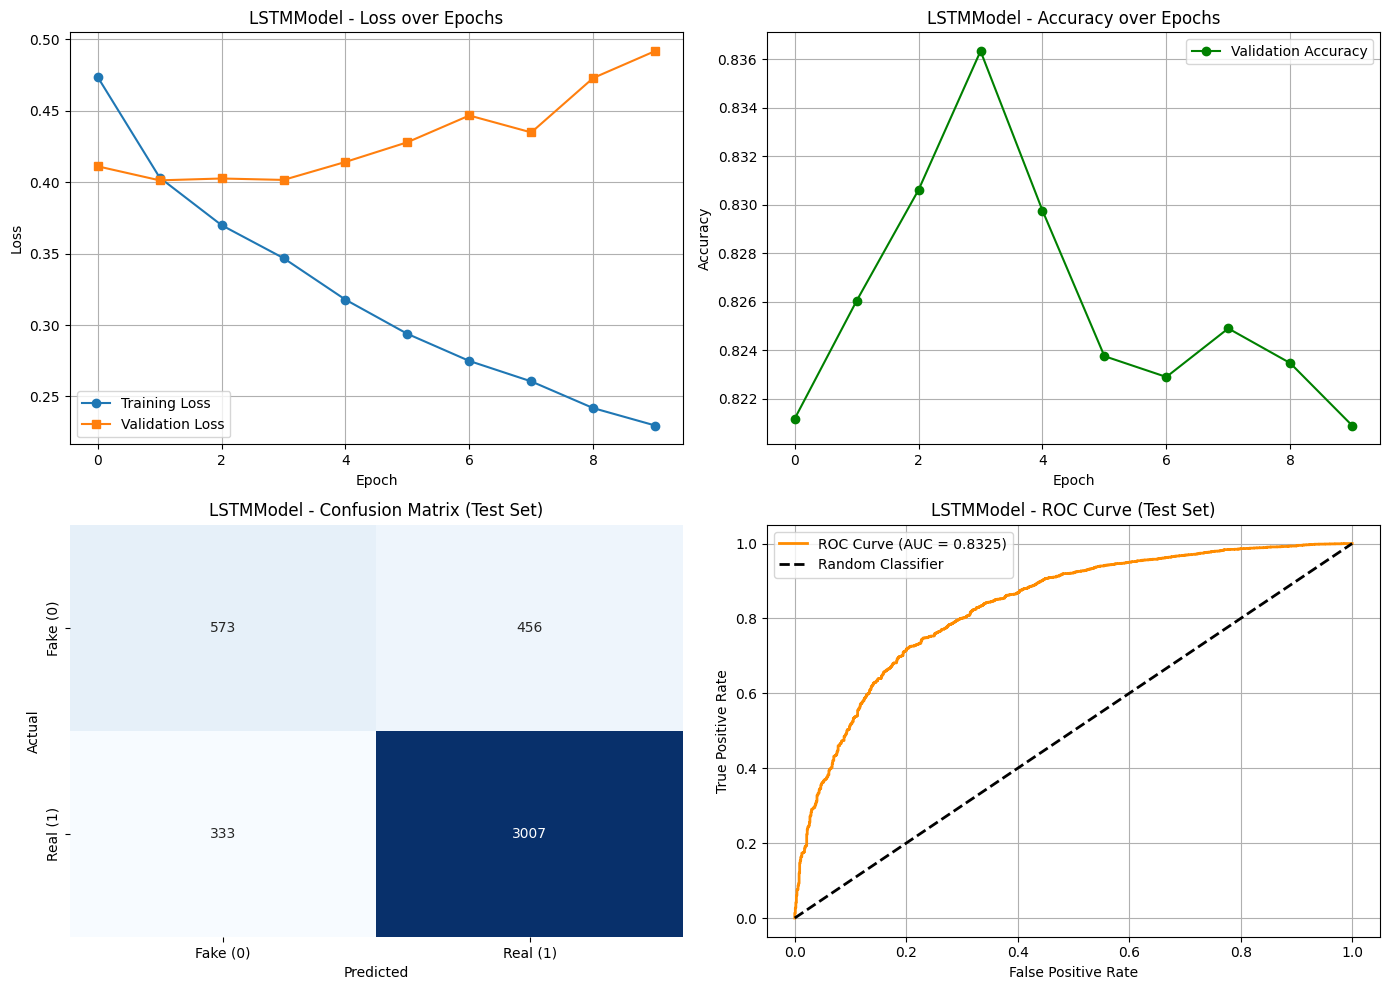


TRAINING CNN-LSTM HYBRID MODEL
Training on device: cuda
Model: CNNLSTMModel


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10] | Train Loss: 0.5656 | Val Loss: 0.5644 | Val Accuracy: 0.7542
Epoch [2/10] | Train Loss: 0.5654 | Val Loss: 0.5616 | Val Accuracy: 0.7542
Epoch [3/10] | Train Loss: 0.5636 | Val Loss: 0.5592 | Val Accuracy: 0.7542
Epoch [4/10] | Train Loss: 0.5641 | Val Loss: 0.5580 | Val Accuracy: 0.7542
Epoch [5/10] | Train Loss: 0.5624 | Val Loss: 0.5583 | Val Accuracy: 0.7542
Epoch [6/10] | Train Loss: 0.5622 | Val Loss: 0.5583 | Val Accuracy: 0.7542
Epoch [7/10] | Train Loss: 0.5613 | Val Loss: 0.5580 | Val Accuracy: 0.7542
Epoch [8/10] | Train Loss: 0.5611 | Val Loss: 0.5617 | Val Accuracy: 0.7542
Epoch [9/10] | Train Loss: 0.5602 | Val Loss: 0.5580 | Val Accuracy: 0.7542
Epoch [10/10] | Train Loss: 0.5604 | Val Loss: 0.5580 | Val Accuracy: 0.7542
CNNLSTMModel training completed!

FINAL EVALUATION ON TEST SET - CNNLSTMModel

Test Accuracy: 0.7645
Test AUC Score: 0.5044

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.00      0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


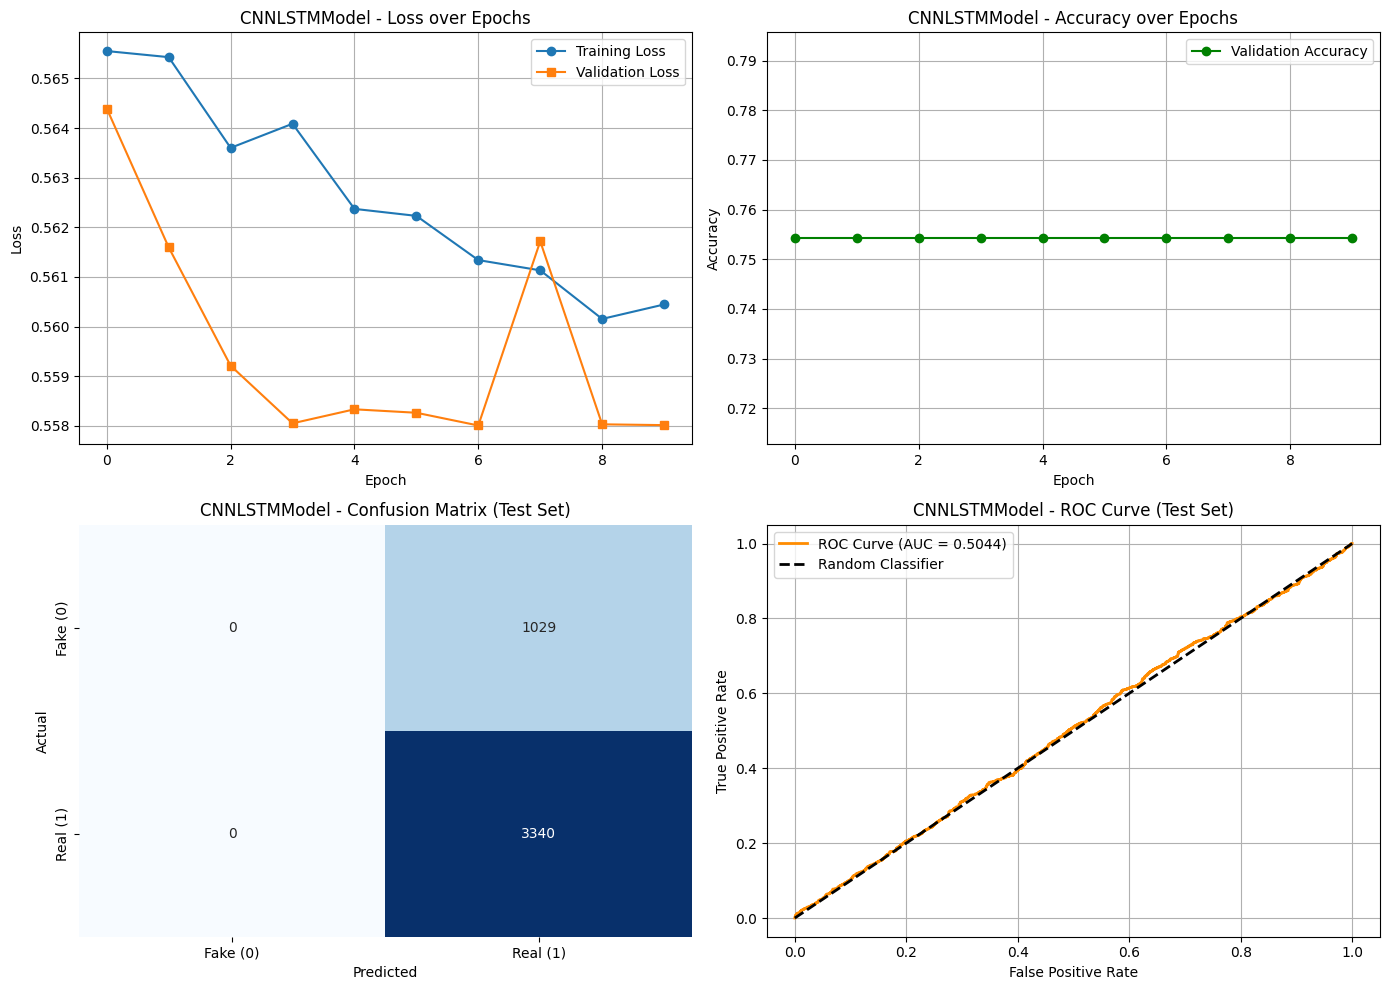


Pipeline completed successfully
GloVe embeddings generated: 300 dimensions
Training samples: 17475
Test samples: 4369
ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)
DL models trained (CNN, LSTM, CNN-LSTM)
  - CNN test accuracy: 0.7645
  - LSTM test accuracy: 0.8194
  - CNN-LSTM test accuracy: 0.7645



In [24]:
#FakeNewsNet

glove_df, xtrain, ytrain, xtest, ytest, models_history = run_complete_pipeline(
    dataset_csv_path='/content/drive/MyDrive/datasets/FakeNewsNet_processed.csv',
    glove_file_path='/content/drive/MyDrive/datasets/dolma_300_2024_1.2M.100_combined.txt'
)